# Autoencoder vs Baseline — Comparison

Comparación cuantitativa y visual del **Level 1 autoencoder** (ae-v1) contra el
**baseline PCA→UMAP→kNN** (poster-v2).

Dimensiones de comparación:
1. **Trustworthiness** — ¿el AE preserva mejor los vecindarios locales?
2. **Estabilidad kNN** — ¿el grafo sobre bottleneck es más estable entre seeds?
3. **UMAP scatter lado a lado** — ¿se revelan nuevos clusters?
4. **Distribución de distancias** — ¿las distancias kNN son más informativas?
5. **Tabla resumen** — comparación compacta para el paper

In [1]:
import json, sys, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import trustworthiness
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)

ROOT = Path("/shared/Code/OXOR")
BASELINE_TAG = "poster-v2"
AE_TAG = "ae-v1"
DATASETS = ["global_snp", "global_silico", "lowdensity_snp", "lowdensity_silico"]
SEEDS = [42, 52, 62]
FIG_DIR = ROOT / "docs" / "figures" / "comparison"
FIG_DIR.mkdir(parents=True, exist_ok=True)
DPI = 300

sys.path.insert(0, str(ROOT / "scripts"))
from load_dart import load_genotypes, filter_missingness
from sklearn.impute import SimpleImputer

def load_nodes(tag, ds, seed):
    if tag == AE_TAG:
        p = ROOT / "experiments" / ds / tag / f"seed{seed}" / "ae_embedding_nodes.json"
    else:
        p = ROOT / "experiments" / ds / tag / f"seed{seed}_{ds}_nodes.json"
    with open(p) as f:
        return json.load(f)

def load_edges(tag, ds, seed):
    if tag == AE_TAG:
        p = ROOT / "experiments" / ds / tag / f"seed{seed}" / "ae_embedding_edges.json"
    else:
        p = ROOT / "experiments" / ds / tag / f"seed{seed}_{ds}_edges.json"
    with open(p) as f:
        return json.load(f)

def load_validation(ds):
    p = ROOT / "experiments" / ds / BASELINE_TAG / f"all_{ds}_validation.json"
    with open(p) as f:
        return json.load(f)

DS_INPUTS = {
    "global_snp": "data/10.21223P30BVZYY_Genetic_diversity/SNP_Genotypes.csv",
    "global_silico": "data/10.21223P30BVZYY_Genetic_diversity/SilicoDArT_Genotypes.csv",
    "lowdensity_snp": "data/10.21223P3UBDJ44_LowDensity/01_Report_DSp25-515_SNPs_Filtered_by _reads.csv",
    "lowdensity_silico": "data/10.21223P3UBDJ44_LowDensity/02_Report_DSp25-515_Silico-DArT_Filtered_by_reads.csv",
}

ds_labels = {
    "global_snp": "Global SNP",
    "global_silico": "Global SilicoDArT",
    "lowdensity_snp": "LowDensity SNP",
    "lowdensity_silico": "LowDensity SilicoDArT",
}

print("✓ Setup ready")

✓ Setup ready


## 1. Trustworthiness — AE bottleneck vs PCA embedding

Comparamos `trustworthiness(X_original, X_reduced, k=15)` donde:
- **Baseline**: `X_reduced` = UMAP 2D (del baseline PCA→UMAP)
- **AE bottleneck**: `X_reduced` = bottleneck 64D del autoencoder
- **AE UMAP**: `X_reduced` = UMAP 2D aplicado al bottleneck

In [2]:
trust_results = []

for ds in DATASETS:
    print(f"\n--- {ds_labels[ds]} ---")
    X_raw, sample_ids, sample_meta = load_genotypes(ROOT / DS_INPUTS[ds])
    X_raw, _ = filter_missingness(X_raw, sample_thresh=0.50, marker_thresh=0.50)
    imp = SimpleImputer(strategy="most_frequent")
    X_high = imp.fit_transform(X_raw)
    sample_ids = list(X_raw.index.astype(str))
    print(f"  X_high shape: {X_high.shape}")
    
    k = 15
    
    for seed in SEEDS:
        # Baseline: trust on UMAP 2D
        b_nodes = load_nodes(BASELINE_TAG, ds, seed)
        b_emb = np.array([n["embedding"] for n in b_nodes])
        trust_baseline = trustworthiness(X_high, b_emb, n_neighbors=min(k, len(b_nodes)-1))
        
        # AE: trust on bottleneck 64D and on UMAP 2D
        ae_nodes = load_nodes(AE_TAG, ds, seed)
        ae_bn = np.array([n["bottleneck"] for n in ae_nodes])
        ae_2d = np.array([n["embedding"] for n in ae_nodes])
        trust_ae_bn = trustworthiness(X_high, ae_bn, n_neighbors=min(k, len(ae_nodes)-1))
        trust_ae_2d = trustworthiness(X_high, ae_2d, n_neighbors=min(k, len(ae_nodes)-1))
        
        trust_results.append({
            "dataset": ds, "seed": seed,
            "trust_baseline_umap2d": trust_baseline,
            "trust_ae_bottleneck64": trust_ae_bn,
            "trust_ae_umap2d": trust_ae_2d,
        })
        print(f"  seed={seed}: baseline={trust_baseline:.4f}  ae_bn={trust_ae_bn:.4f}  ae_umap={trust_ae_2d:.4f}")

trust_df = pd.DataFrame(trust_results)
print("\n✓ Trustworthiness computed")


--- Global SNP ---
  X_high shape: (5970, 20069)
  seed=42: baseline=0.9806  ae_bn=0.9881  ae_umap=0.9611
  seed=52: baseline=0.9812  ae_bn=0.9888  ae_umap=0.9646
  seed=62: baseline=0.9787  ae_bn=0.9867  ae_umap=0.9605

--- Global SilicoDArT ---
  X_high shape: (5970, 57715)
  seed=42: baseline=0.9843  ae_bn=0.9898  ae_umap=0.9736
  seed=52: baseline=0.9838  ae_bn=0.9889  ae_umap=0.9752
  seed=62: baseline=0.9843  ae_bn=0.9880  ae_umap=0.9711

--- LowDensity SNP ---
  X_high shape: (630, 62732)
  seed=42: baseline=0.9353  ae_bn=0.8288  ae_umap=0.7917
  seed=52: baseline=0.9303  ae_bn=0.8169  ae_umap=0.7611
  seed=62: baseline=0.9327  ae_bn=0.8623  ae_umap=0.8265

--- LowDensity SilicoDArT ---
  X_high shape: (635, 38272)
  seed=42: baseline=0.9022  ae_bn=0.8375  ae_umap=0.8009
  seed=52: baseline=0.9063  ae_bn=0.8040  ae_umap=0.7651
  seed=62: baseline=0.9128  ae_bn=0.8450  ae_umap=0.8175

✓ Trustworthiness computed


### Fig 01 — Trustworthiness comparison

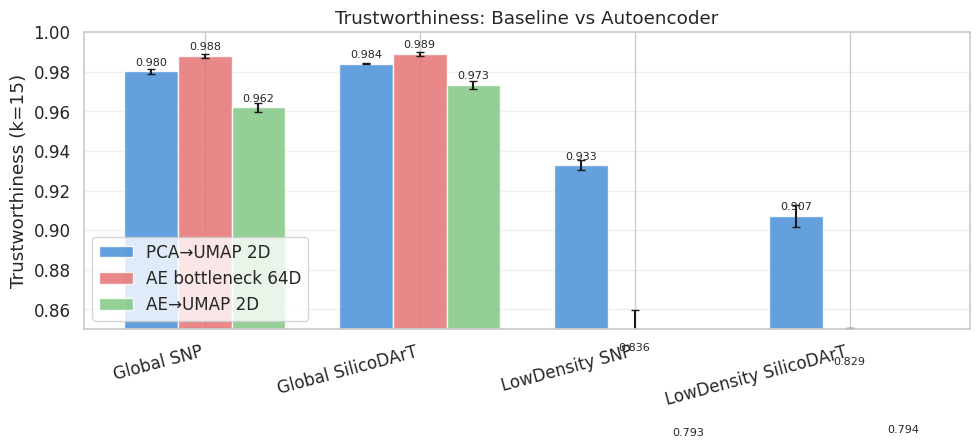

✓ Saved


In [3]:
trust_agg = trust_df.groupby("dataset").agg(
    baseline_mean=("trust_baseline_umap2d", "mean"),
    baseline_std=("trust_baseline_umap2d", "std"),
    ae_bn_mean=("trust_ae_bottleneck64", "mean"),
    ae_bn_std=("trust_ae_bottleneck64", "std"),
    ae_umap_mean=("trust_ae_umap2d", "mean"),
    ae_umap_std=("trust_ae_umap2d", "std"),
).reindex(DATASETS)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(DATASETS))
w = 0.25

bars1 = ax.bar(x - w, trust_agg["baseline_mean"], w, yerr=trust_agg["baseline_std"],
               label="PCA→UMAP 2D", color="#4A90D9", capsize=3, alpha=0.85)
bars2 = ax.bar(x, trust_agg["ae_bn_mean"], w, yerr=trust_agg["ae_bn_std"],
               label="AE bottleneck 64D", color="#E57373", capsize=3, alpha=0.85)
bars3 = ax.bar(x + w, trust_agg["ae_umap_mean"], w, yerr=trust_agg["ae_umap_std"],
               label="AE→UMAP 2D", color="#81C784", capsize=3, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([ds_labels[d] for d in DATASETS], rotation=15, ha="right")
ax.set_ylabel("Trustworthiness (k=15)")
ax.set_title("Trustworthiness: Baseline vs Autoencoder")
ax.legend(loc="lower left")
ax.set_ylim(0.85, 1.0)
ax.grid(axis="y", alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.002, f"{h:.3f}",
                ha="center", va="bottom", fontsize=8)

fig.tight_layout()
fig.savefig(FIG_DIR / "01_trustworthiness_comparison.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("✓ Saved")

## 2. Estabilidad kNN entre seeds

Comparamos el Jaccard de aristas y vecindarios kNN entre pares de seeds para:
- **Baseline**: grafo kNN del pipeline PCA
- **AE**: grafo kNN construido sobre bottleneck 64D

In [3]:
def compute_knn_jaccard(edges1, edges2):
    set1 = {(e["source"], e["target"]) for e in edges1}
    set2 = {(e["source"], e["target"]) for e in edges2}
    inter = len(set1 & set2)
    union = len(set1 | set2)
    return inter / union if union > 0 else 1.0

def compute_neighbor_jaccard(edges1, edges2, ids):
    def neighbors_dict(edges):
        d = {}
        for e in edges:
            d.setdefault(e["source"], set()).add(e["target"])
        return d
    n1, n2 = neighbors_dict(edges1), neighbors_dict(edges2)
    jaccards = []
    for nid in ids:
        s1, s2 = n1.get(nid, set()), n2.get(nid, set())
        u = len(s1 | s2)
        jaccards.append(len(s1 & s2) / u if u > 0 else 1.0)
    return np.mean(jaccards)

stability_results = []
seed_pairs = [(42, 52), (42, 62), (52, 62)]

for ds in DATASETS:
    print(f"\n--- {ds_labels[ds]} ---")
    ae_nodes = load_nodes(AE_TAG, ds, 42)
    ids = [n["id"] for n in ae_nodes]
    
    for s1, s2 in seed_pairs:
        b_e1, b_e2 = load_edges(BASELINE_TAG, ds, s1), load_edges(BASELINE_TAG, ds, s2)
        ae_e1, ae_e2 = load_edges(AE_TAG, ds, s1), load_edges(AE_TAG, ds, s2)
        
        stability_results.append({
            "dataset": ds, "seeds": f"{s1}-{s2}",
            "baseline_edge_jaccard": compute_knn_jaccard(b_e1, b_e2),
            "baseline_neigh_jaccard": compute_neighbor_jaccard(b_e1, b_e2, ids),
            "ae_edge_jaccard": compute_knn_jaccard(ae_e1, ae_e2),
            "ae_neigh_jaccard": compute_neighbor_jaccard(ae_e1, ae_e2, ids),
        })
        print(f"  {s1}-{s2}: baseline_J={stability_results[-1]['baseline_edge_jaccard']:.4f}  ae_J={stability_results[-1]['ae_edge_jaccard']:.4f}")

stab_df = pd.DataFrame(stability_results)
print("\n✓ Stability computed")


--- Global SNP ---
  42-52: baseline_J=0.8911  ae_J=0.5250
  42-62: baseline_J=0.8882  ae_J=0.5184
  52-62: baseline_J=0.8852  ae_J=0.5270

--- Global SilicoDArT ---
  42-52: baseline_J=0.8848  ae_J=0.5042
  42-62: baseline_J=0.8713  ae_J=0.4915
  52-62: baseline_J=0.8982  ae_J=0.4994

--- LowDensity SNP ---
  42-52: baseline_J=0.9135  ae_J=0.1545
  42-62: baseline_J=0.9031  ae_J=0.1704
  52-62: baseline_J=0.9089  ae_J=0.1642

--- LowDensity SilicoDArT ---
  42-52: baseline_J=0.9081  ae_J=0.2023
  42-62: baseline_J=0.9079  ae_J=0.2193
  52-62: baseline_J=0.9092  ae_J=0.2008

✓ Stability computed


### Fig 02 — kNN stability comparison

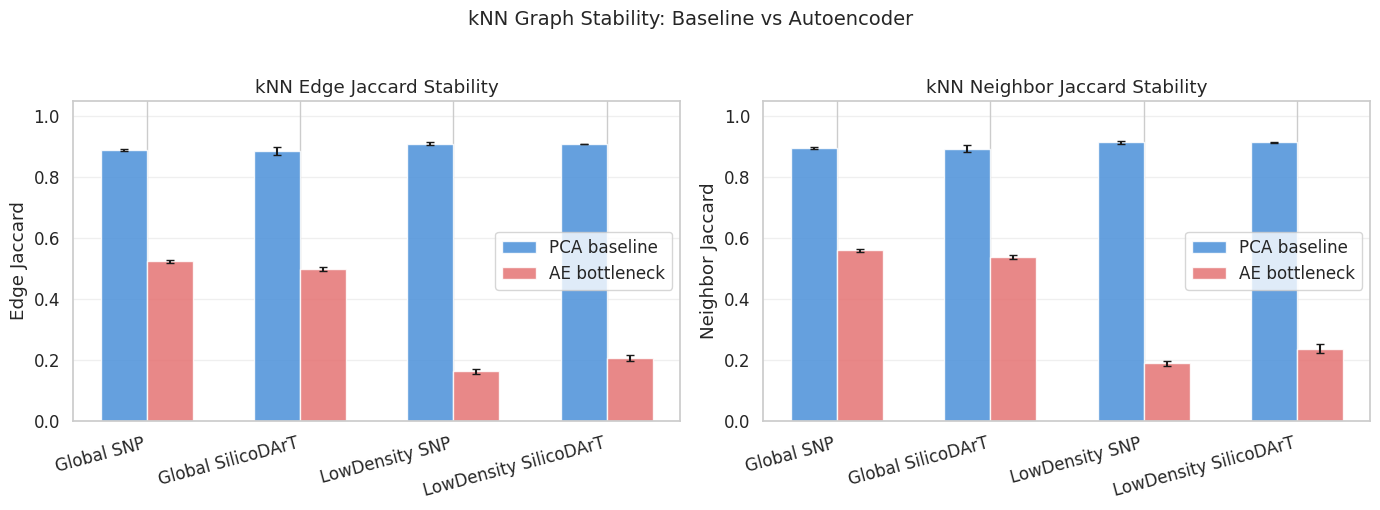

✓ Saved


In [5]:
stab_agg = stab_df.groupby("dataset").agg(
    b_edge_m=("baseline_edge_jaccard", "mean"), b_edge_s=("baseline_edge_jaccard", "std"),
    ae_edge_m=("ae_edge_jaccard", "mean"), ae_edge_s=("ae_edge_jaccard", "std"),
    b_neigh_m=("baseline_neigh_jaccard", "mean"), b_neigh_s=("baseline_neigh_jaccard", "std"),
    ae_neigh_m=("ae_neigh_jaccard", "mean"), ae_neigh_s=("ae_neigh_jaccard", "std"),
).reindex(DATASETS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(DATASETS))
w = 0.3

for i, (title, b_m, b_s, a_m, a_s) in enumerate([
    ("Edge Jaccard", "b_edge_m", "b_edge_s", "ae_edge_m", "ae_edge_s"),
    ("Neighbor Jaccard", "b_neigh_m", "b_neigh_s", "ae_neigh_m", "ae_neigh_s"),
]):
    ax = axes[i]
    ax.bar(x - w/2, stab_agg[b_m], w, yerr=stab_agg[b_s],
           label="PCA baseline", color="#4A90D9", capsize=3, alpha=0.85)
    ax.bar(x + w/2, stab_agg[a_m], w, yerr=stab_agg[a_s],
           label="AE bottleneck", color="#E57373", capsize=3, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([ds_labels[d] for d in DATASETS], rotation=15, ha="right")
    ax.set_ylabel(title)
    ax.set_title(f"kNN {title} Stability")
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("kNN Graph Stability: Baseline vs Autoencoder", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_stability_comparison.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("✓ Saved")

## 3. UMAP scatter — side by side

Baseline (PCA→UMAP) vs AE (bottleneck→UMAP), seed=42.

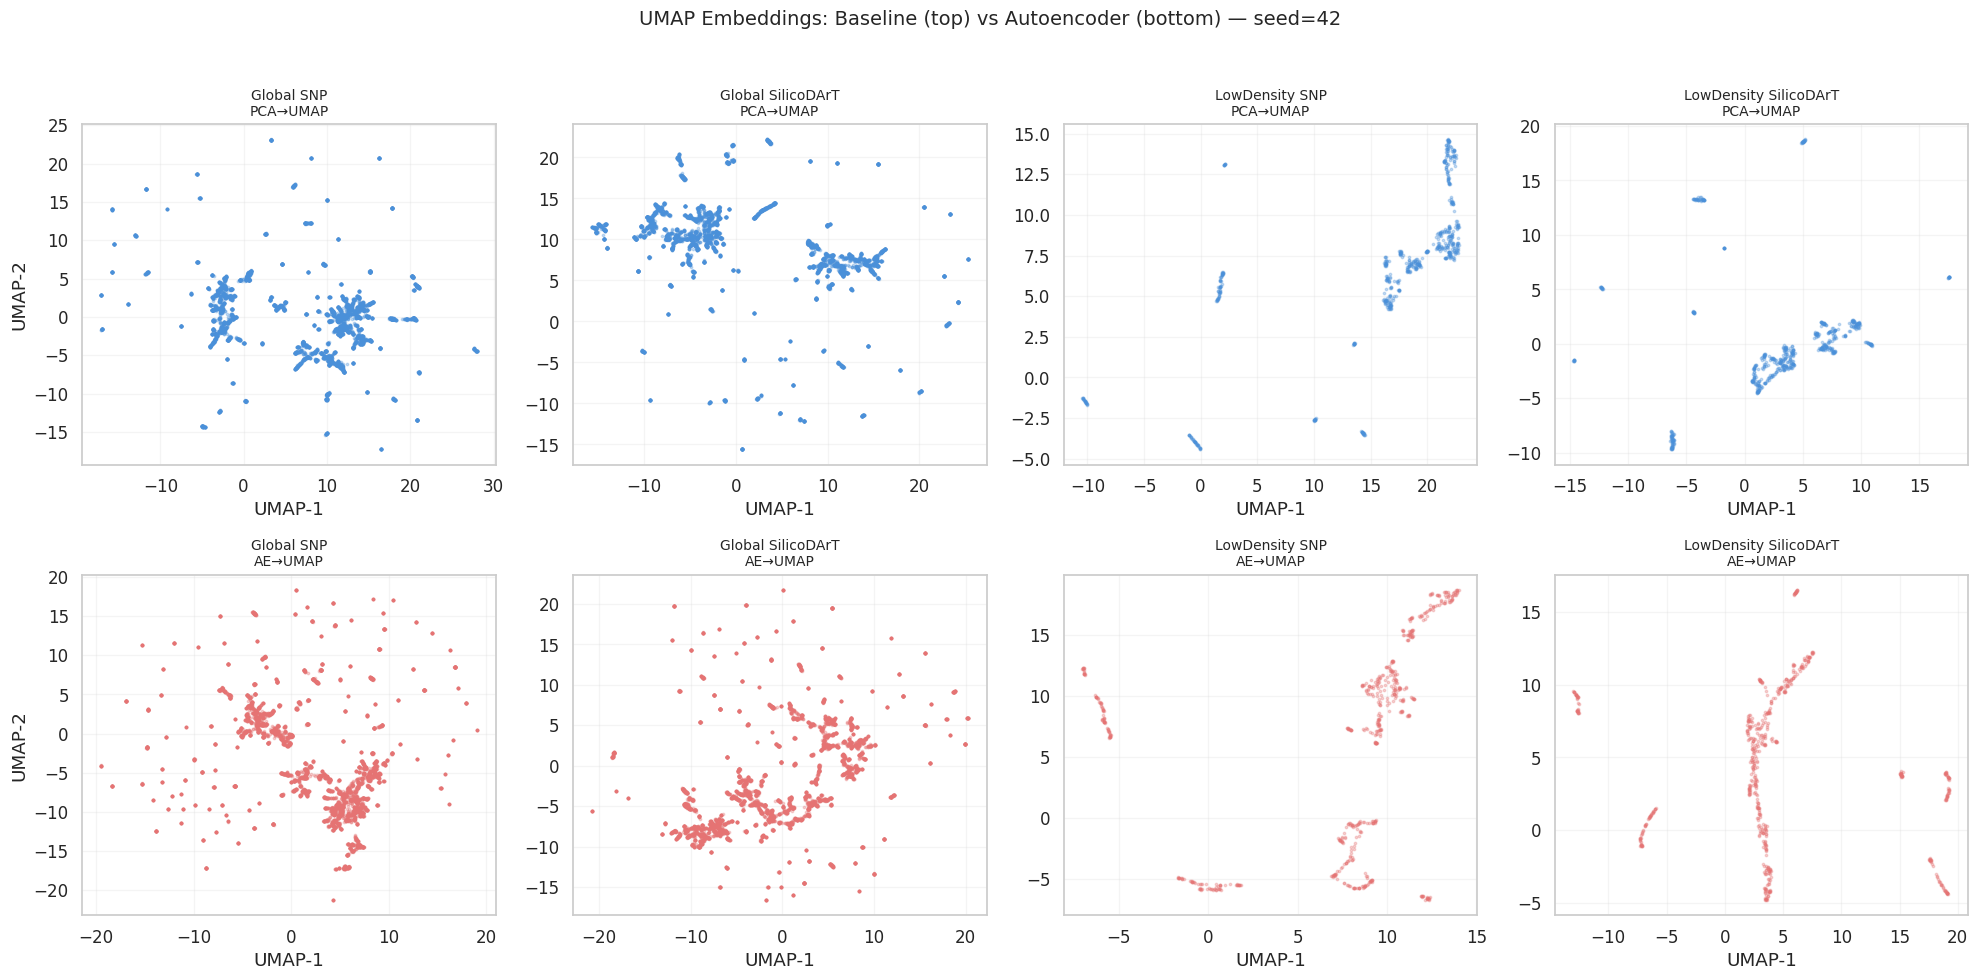

✓ Saved


In [6]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for col, ds in enumerate(DATASETS):
    b_nodes = load_nodes(BASELINE_TAG, ds, 42)
    b_emb = np.array([n["embedding"] for n in b_nodes])
    ax = axes[0, col]
    ax.scatter(b_emb[:, 0], b_emb[:, 1], s=3, alpha=0.3, c="#4A90D9")
    ax.set_title(f"{ds_labels[ds]}\nPCA→UMAP", fontsize=10)
    ax.set_xlabel("UMAP-1")
    if col == 0: ax.set_ylabel("UMAP-2")
    ax.grid(alpha=0.2)

    ae_nodes = load_nodes(AE_TAG, ds, 42)
    ae_emb = np.array([n["embedding"] for n in ae_nodes])
    ax = axes[1, col]
    ax.scatter(ae_emb[:, 0], ae_emb[:, 1], s=3, alpha=0.3, c="#E57373")
    ax.set_title(f"{ds_labels[ds]}\nAE→UMAP", fontsize=10)
    ax.set_xlabel("UMAP-1")
    if col == 0: ax.set_ylabel("UMAP-2")
    ax.grid(alpha=0.2)

fig.suptitle("UMAP Embeddings: Baseline (top) vs Autoencoder (bottom) — seed=42", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / "03_umap_side_by_side.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("✓ Saved")

## 4. Distribución de distancias kNN

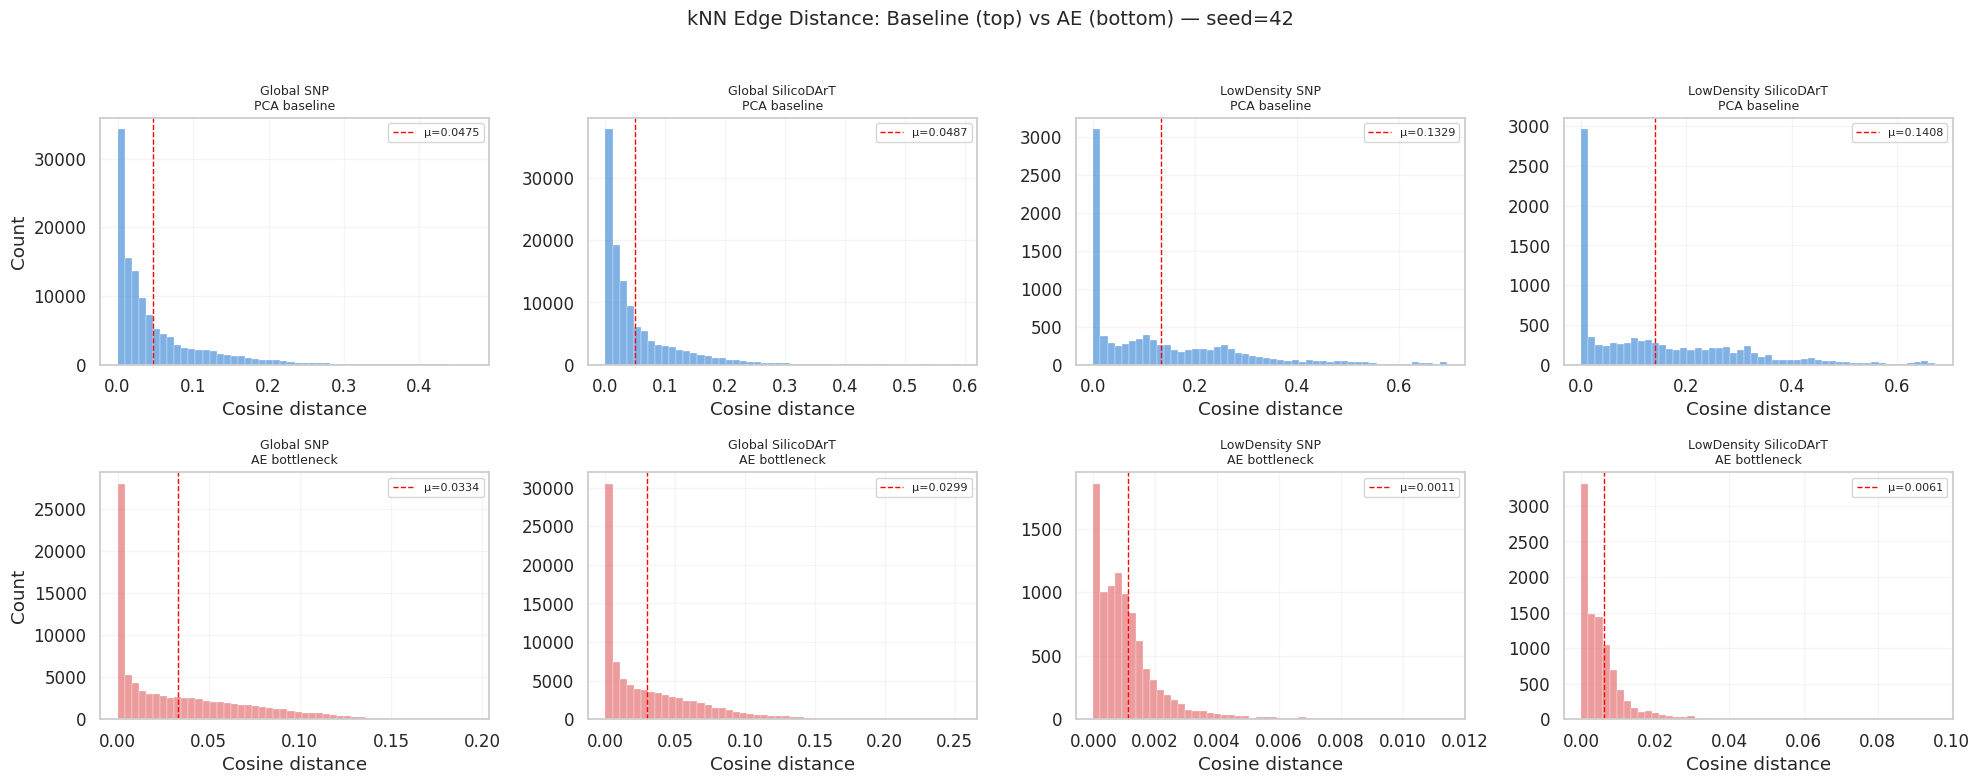

✓ Saved


In [7]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for col, ds in enumerate(DATASETS):
    for row, (tag, color, label) in enumerate([
        (BASELINE_TAG, "#4A90D9", "PCA baseline"),
        (AE_TAG, "#E57373", "AE bottleneck"),
    ]):
        edges = load_edges(tag, ds, 42)
        dists = [e["distance"] for e in edges]
        ax = axes[row, col]
        ax.hist(dists, bins=50, color=color, alpha=0.7, edgecolor="white", linewidth=0.3)
        ax.axvline(np.mean(dists), color="red", ls="--", lw=1, label=f"μ={np.mean(dists):.4f}")
        ax.set_title(f"{ds_labels[ds]}\n{label}", fontsize=9)
        ax.legend(fontsize=8)
        if col == 0: ax.set_ylabel("Count")
        ax.set_xlabel("Cosine distance")
        ax.grid(alpha=0.2)

fig.suptitle("kNN Edge Distance: Baseline (top) vs AE (bottom) — seed=42", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / "04_distance_comparison.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("✓ Saved")

## 5. AE Training Curves

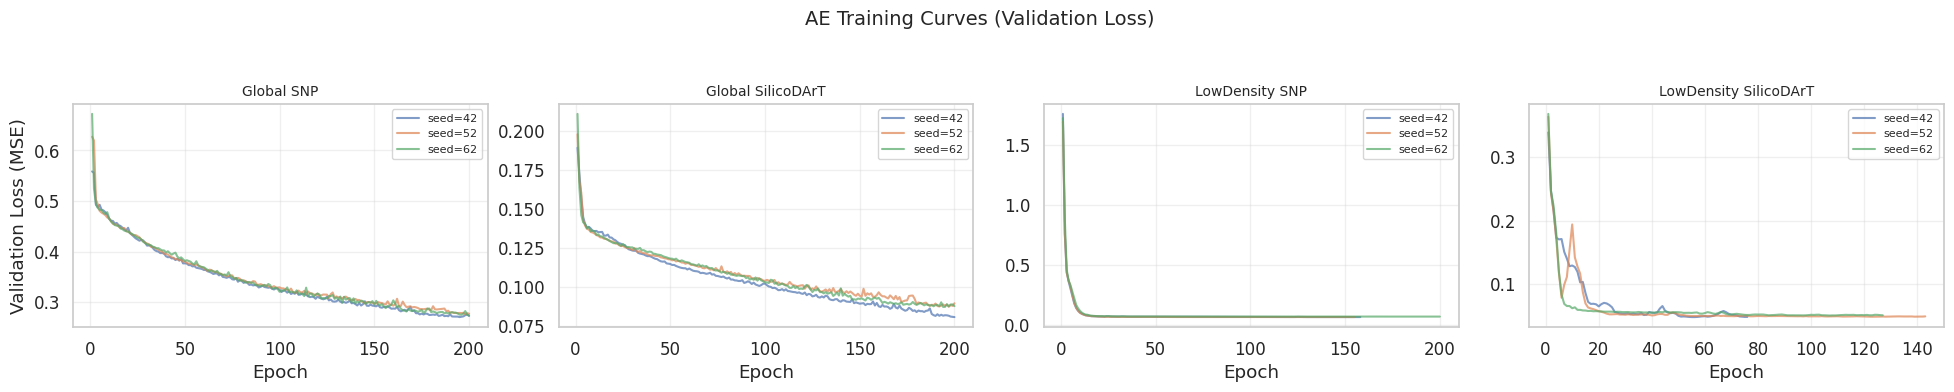

✓ Saved


In [8]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for col, ds in enumerate(DATASETS):
    ax = axes[col]
    for seed in SEEDS:
        hp = ROOT / "experiments" / ds / AE_TAG / f"seed{seed}" / "training_history.json"
        with open(hp) as f:
            hist = json.load(f)
        ep = range(1, len(hist["val_loss"]) + 1)
        ax.plot(ep, hist["val_loss"], alpha=0.7, label=f"seed={seed}")
    ax.set_title(ds_labels[ds], fontsize=10)
    ax.set_xlabel("Epoch")
    if col == 0: ax.set_ylabel("Validation Loss (MSE)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle("AE Training Curves (Validation Loss)", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(FIG_DIR / "05_ae_training_curves.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("✓ Saved")

## 6. Summary Table

In [9]:
rows = []
for ds in DATASETS:
    val = load_validation(ds)
    b_t_m = val["trustworthiness"]["mean"]
    b_t_s = val["trustworthiness"]["std"]
    
    ae_t = trust_df[trust_df["dataset"] == ds]
    ae_bn_m = ae_t["trust_ae_bottleneck64"].mean()
    ae_bn_s = ae_t["trust_ae_bottleneck64"].std()
    ae_2d_m = ae_t["trust_ae_umap2d"].mean()
    
    stab = stab_df[stab_df["dataset"] == ds]
    b_stab = stab["baseline_edge_jaccard"].mean()
    ae_stab = stab["ae_edge_jaccard"].mean()
    
    vl = []
    for seed in SEEDS:
        sp = ROOT / "experiments" / ds / AE_TAG / f"seed{seed}" / "ae_embedding_stats.json"
        with open(sp) as f: s = json.load(f)
        vl.append(s["best_val_loss"])
    
    rows.append({
        "Dataset": ds_labels[ds],
        "Trust (PCA 2D)": f"{b_t_m:.4f}±{b_t_s:.4f}",
        "Trust (AE 64D)": f"{ae_bn_m:.4f}±{ae_bn_s:.4f}",
        "Trust (AE 2D)": f"{ae_2d_m:.4f}",
        "Δ Trust": f"{ae_bn_m - b_t_m:+.4f}",
        "Stab PCA": f"{b_stab:.4f}",
        "Stab AE": f"{ae_stab:.4f}",
        "AE val loss": f"{np.mean(vl):.4f}±{np.std(vl):.4f}",
    })

summary_df = pd.DataFrame(rows)
summary_df.style.set_caption("Baseline (PCA→UMAP) vs Autoencoder (Level 1) — Comparison")

,Dataset,Trust (PCA 2D),Trust (AE 64D),Trust (AE 2D),Δ Trust,Stab PCA,Stab AE,AE val loss
0,Global SNP,0.9756±0.0017,0.9879±0.0011,0.9621,+0.0123,0.8882,0.5235,0.2737±0.0023
1,Global SilicoDArT,0.9792±0.0006,0.9889±0.0009,0.9733,+0.0097,0.8848,0.4983,0.0850±0.0031
2,LowDensity SNP,0.9334±0.0018,0.8360±0.0236,0.7931,-0.0974,0.9085,0.1630,0.0669±0.0019
3,LowDensity SilicoDArT,0.9105±0.0046,0.8288±0.0218,0.7945,-0.0817,0.9084,0.2075,0.0494±0.0010


---
# ae-v2: Regularización agresiva + Ensemble + Transfer Learning

Mejoras sobre ae-v1:
- **Regularización agresiva** para LowDensity: dropout=0.45, noise=0.30, weight_decay=5e-4
- **Ensemble**: promedio de bottleneck entre seeds → embedding estable
- **Transfer learning**: pre-train en Global SNP → fine-tune en LowDensity
- **50 epochs** (basado en análisis de curvas de ae-v1: convergencia antes de epoch 50)

In [4]:
## ── ae-v2 setup ──────────────────────────────────────────────
AE_V2_TAG = "ae-v2"

def load_nodes_v2(ds, variant="seed42"):
    """Load nodes from ae-v2 (seed, ensemble, or transfer)."""
    p = ROOT / "experiments" / ds / AE_V2_TAG / variant / "ae_embedding_nodes.json"
    with open(p) as f:
        return json.load(f)

def load_edges_v2(ds, variant="seed42"):
    p = ROOT / "experiments" / ds / AE_V2_TAG / variant / "ae_embedding_edges.json"
    with open(p) as f:
        return json.load(f)

# Discover available variants per dataset
for ds in DATASETS:
    base = ROOT / "experiments" / ds / AE_V2_TAG
    variants = sorted([d.name for d in base.iterdir() if d.is_dir()])
    print(f"{ds_labels[ds]:25s}: {variants}")

print("\n✓ ae-v2 setup ready")

Global SNP               : ['ensemble', 'seed42', 'seed52', 'seed62']
Global SilicoDArT        : ['ensemble', 'seed42', 'seed52', 'seed62']
LowDensity SNP           : ['ensemble', 'ensemble_transfer', 'seed42', 'seed42_transfer', 'seed52', 'seed52_transfer', 'seed62', 'seed62_transfer']
LowDensity SilicoDArT    : ['ensemble', 'ensemble_transfer', 'seed42', 'seed42_transfer', 'seed52', 'seed52_transfer', 'seed62', 'seed62_transfer']

✓ ae-v2 setup ready


## 7. Trustworthiness — ae-v2 (regularización + ensemble + transfer)

In [5]:
trust_v2_results = []

for ds in DATASETS:
    print(f"\n--- {ds_labels[ds]} ---")
    X_raw, sample_ids, sample_meta = load_genotypes(ROOT / DS_INPUTS[ds])
    X_raw, _ = filter_missingness(X_raw, sample_thresh=0.50, marker_thresh=0.50)
    imp = SimpleImputer(strategy="most_frequent")
    X_high = imp.fit_transform(X_raw)
    sample_ids = list(X_raw.index.astype(str))
    k = 15
    
    # ae-v2 individual seeds (regularized)
    for seed in SEEDS:
        nodes = load_nodes_v2(ds, f"seed{seed}")
        bn = np.array([n["bottleneck"] for n in nodes])
        emb2d = np.array([n["embedding"] for n in nodes])
        t_bn = trustworthiness(X_high, bn, n_neighbors=min(k, len(nodes)-1))
        t_2d = trustworthiness(X_high, emb2d, n_neighbors=min(k, len(nodes)-1))
        trust_v2_results.append({
            "dataset": ds, "seed": seed, "variant": "v2_reg",
            "trust_bn": t_bn, "trust_2d": t_2d,
        })
        print(f"  v2_reg seed={seed}: bn={t_bn:.4f}  2d={t_2d:.4f}")
    
    # ae-v2 ensemble
    try:
        ens_nodes = load_nodes_v2(ds, "ensemble")
        ens_bn = np.array([n["bottleneck"] for n in ens_nodes])
        ens_2d = np.array([n["embedding"] for n in ens_nodes])
        t_bn = trustworthiness(X_high, ens_bn, n_neighbors=min(k, len(ens_nodes)-1))
        t_2d = trustworthiness(X_high, ens_2d, n_neighbors=min(k, len(ens_nodes)-1))
        trust_v2_results.append({
            "dataset": ds, "seed": "ens", "variant": "v2_ensemble",
            "trust_bn": t_bn, "trust_2d": t_2d,
        })
        print(f"  v2_ensemble:       bn={t_bn:.4f}  2d={t_2d:.4f}")
    except Exception as e:
        print(f"  v2_ensemble: SKIP ({e})")
    
    # ae-v2 transfer (only for lowdensity)
    if "lowdensity" in ds:
        for seed in SEEDS:
            try:
                t_nodes = load_nodes_v2(ds, f"seed{seed}_transfer")
                t_bn = np.array([n["bottleneck"] for n in t_nodes])
                t_2d = np.array([n["embedding"] for n in t_nodes])
                t_trust = trustworthiness(X_high, t_bn, n_neighbors=min(k, len(t_nodes)-1))
                trust_v2_results.append({
                    "dataset": ds, "seed": seed, "variant": "v2_transfer",
                    "trust_bn": t_trust,
                    "trust_2d": trustworthiness(X_high, t_2d, n_neighbors=min(k, len(t_nodes)-1)),
                })
                print(f"  v2_transfer seed={seed}: bn={t_trust:.4f}")
            except Exception as e:
                print(f"  v2_transfer seed={seed}: SKIP ({e})")
        
        # Transfer ensemble
        try:
            te_nodes = load_nodes_v2(ds, "ensemble_transfer")
            te_bn = np.array([n["bottleneck"] for n in te_nodes])
            te_2d = np.array([n["embedding"] for n in te_nodes])
            t_trust = trustworthiness(X_high, te_bn, n_neighbors=min(k, len(te_nodes)-1))
            trust_v2_results.append({
                "dataset": ds, "seed": "ens_t", "variant": "v2_transfer_ens",
                "trust_bn": t_trust,
                "trust_2d": trustworthiness(X_high, te_2d, n_neighbors=min(k, len(te_nodes)-1)),
            })
            print(f"  v2_transfer_ens:   bn={t_trust:.4f}")
        except Exception as e:
            print(f"  v2_transfer_ens: SKIP ({e})")

trust_v2_df = pd.DataFrame(trust_v2_results)
print("\n✓ ae-v2 trustworthiness computed")


--- Global SNP ---
  v2_reg seed=42: bn=0.9817  2d=0.9699
  v2_reg seed=52: bn=0.9834  2d=0.9712
  v2_reg seed=62: bn=0.9815  2d=0.9666
  v2_ensemble:       bn=0.9847  2d=0.9667

--- Global SilicoDArT ---
  v2_reg seed=42: bn=0.9788  2d=0.9712
  v2_reg seed=52: bn=0.9771  2d=0.9692
  v2_reg seed=62: bn=0.9743  2d=0.9655
  v2_ensemble:       bn=0.9799  2d=0.9689

--- LowDensity SNP ---
  v2_reg seed=42: bn=0.8835  2d=0.8432
  v2_reg seed=52: bn=0.8850  2d=0.8526
  v2_reg seed=62: bn=0.7630  2d=0.7347
  v2_ensemble:       bn=0.7844  2d=0.7763
  v2_transfer seed=42: bn=0.6243
  v2_transfer seed=52: bn=0.6267
  v2_transfer seed=62: bn=0.7241
  v2_transfer_ens:   bn=0.7666

--- LowDensity SilicoDArT ---
  v2_reg seed=42: bn=0.8513  2d=0.8197
  v2_reg seed=52: bn=0.8556  2d=0.7987
  v2_reg seed=62: bn=0.8525  2d=0.8012
  v2_ensemble:       bn=0.7704  2d=0.7611
  v2_transfer seed=42: bn=0.7443
  v2_transfer seed=52: bn=0.7858
  v2_transfer seed=62: bn=0.7849
  v2_transfer_ens:   bn=0.8232

✓

### Fig 06 — Trustworthiness: baseline vs ae-v1 vs ae-v2 variants

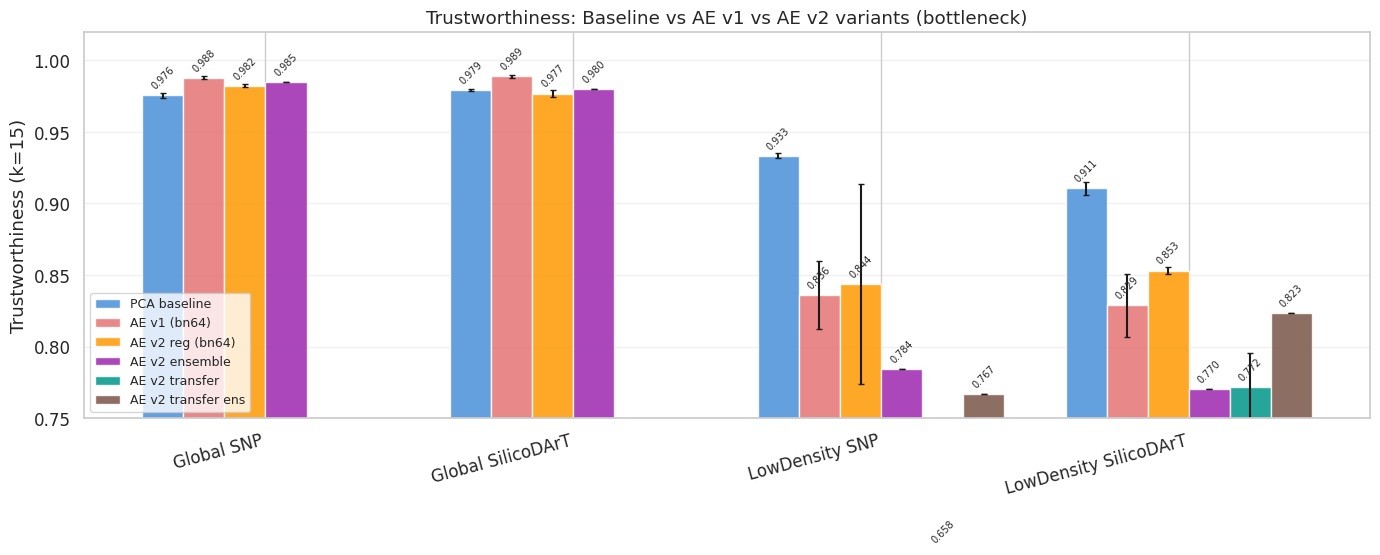

✓ Saved


In [7]:
# Aggregate all trust results into a single comparison
methods = {
    "PCA baseline": {},
    "AE v1 (bn64)": {},
    "AE v2 reg (bn64)": {},
    "AE v2 ensemble": {},
}

for ds in DATASETS:
    # baseline (from ae-v1 comparison)
    val = load_validation(ds)
    methods["PCA baseline"][ds] = (val["trustworthiness"]["mean"], val["trustworthiness"]["std"])
    
    # ae-v1
    v1 = trust_df[trust_df["dataset"] == ds]["trust_ae_bottleneck64"]
    methods["AE v1 (bn64)"][ds] = (v1.mean(), v1.std())
    
    # ae-v2 regularized (individual seeds)
    v2_reg = trust_v2_df[(trust_v2_df["dataset"] == ds) & (trust_v2_df["variant"] == "v2_reg")]
    if len(v2_reg) > 0:
        methods["AE v2 reg (bn64)"][ds] = (v2_reg["trust_bn"].mean(), v2_reg["trust_bn"].std())
    
    # ae-v2 ensemble
    v2_ens = trust_v2_df[(trust_v2_df["dataset"] == ds) & (trust_v2_df["variant"] == "v2_ensemble")]
    if len(v2_ens) > 0:
        methods["AE v2 ensemble"][ds] = (v2_ens["trust_bn"].values[0], 0.0)

# Add transfer variants for lowdensity only
methods["AE v2 transfer"] = {}
methods["AE v2 transfer ens"] = {}
for ds in ["lowdensity_snp", "lowdensity_silico"]:
    v2_tf = trust_v2_df[(trust_v2_df["dataset"] == ds) & (trust_v2_df["variant"] == "v2_transfer")]
    if len(v2_tf) > 0:
        methods["AE v2 transfer"][ds] = (v2_tf["trust_bn"].mean(), v2_tf["trust_bn"].std())
    v2_te = trust_v2_df[(trust_v2_df["dataset"] == ds) & (trust_v2_df["variant"] == "v2_transfer_ens")]
    if len(v2_te) > 0:
        methods["AE v2 transfer ens"][ds] = (v2_te["trust_bn"].values[0], 0.0)

# Filter out empty methods
methods = {k: v for k, v in methods.items() if v}

colors = ["#4A90D9", "#E57373", "#FF9800", "#9C27B0", "#009688", "#795548"]
fig, ax = plt.subplots(figsize=(14, 6))
n_methods = len(methods)
x = np.arange(len(DATASETS))
w = 0.8 / n_methods

for i, (method, ds_vals) in enumerate(methods.items()):
    means, stds = [], []
    for ds in DATASETS:
        if ds in ds_vals:
            means.append(ds_vals[ds][0])
            stds.append(ds_vals[ds][1])
        else:
            means.append(0)
            stds.append(0)
    offset = (i - n_methods / 2 + 0.5) * w
    bars = ax.bar(x + offset, means, w, yerr=stds, label=method,
                  color=colors[i % len(colors)], capsize=2, alpha=0.85)
    for bar, m in zip(bars, means):
        if m > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                    f"{m:.3f}", ha="center", va="bottom", fontsize=7, rotation=45)

ax.set_xticks(x)
ax.set_xticklabels([ds_labels[d] for d in DATASETS], rotation=15, ha="right")
ax.set_ylabel("Trustworthiness (k=15)")
ax.set_title("Trustworthiness: Baseline vs AE v1 vs AE v2 variants (bottleneck)")
ax.legend(fontsize=9, loc="lower left")
ax.set_ylim(0.75, 1.02)
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / "06_trust_v2_comparison.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("✓ Saved")

## 8. Estabilidad kNN — ae-v2 seeds vs ensemble

La estabilidad del ensemble se mide comparando el grafo kNN de cada seed contra el grafo del ensemble. Si el ensemble estabiliza, el Jaccard seed↔ensemble debe ser alto.

In [6]:
# Stability: ae-v2 seed-to-seed AND seed-to-ensemble
stab_v2_results = []

for ds in DATASETS:
    print(f"\n--- {ds_labels[ds]} ---")
    
    # ae-v2 seed-to-seed (same as before)
    for s1, s2 in seed_pairs:
        e1 = load_edges_v2(ds, f"seed{s1}")
        e2 = load_edges_v2(ds, f"seed{s2}")
        j = compute_knn_jaccard(e1, e2)
        stab_v2_results.append({
            "dataset": ds, "comparison": f"v2 s{s1}-s{s2}",
            "type": "v2_seed2seed", "jaccard": j,
        })
        print(f"  v2 seed {s1}-{s2}: J={j:.4f}")
    
    # ae-v2 seed-to-ensemble
    ens_edges = load_edges_v2(ds, "ensemble")
    for seed in SEEDS:
        se = load_edges_v2(ds, f"seed{seed}")
        j = compute_knn_jaccard(se, ens_edges)
        stab_v2_results.append({
            "dataset": ds, "comparison": f"v2 s{seed}-ens",
            "type": "v2_seed2ens", "jaccard": j,
        })
        print(f"  v2 seed{seed}↔ensemble: J={j:.4f}")
    
    # ae-v1 seed-to-seed for reference
    for s1, s2 in seed_pairs:
        e1 = load_edges(AE_TAG, ds, s1)
        e2 = load_edges(AE_TAG, ds, s2)
        j = compute_knn_jaccard(e1, e2)
        stab_v2_results.append({
            "dataset": ds, "comparison": f"v1 s{s1}-s{s2}",
            "type": "v1_seed2seed", "jaccard": j,
        })
    
    # baseline seed-to-seed
    for s1, s2 in seed_pairs:
        e1 = load_edges(BASELINE_TAG, ds, s1)
        e2 = load_edges(BASELINE_TAG, ds, s2)
        j = compute_knn_jaccard(e1, e2)
        stab_v2_results.append({
            "dataset": ds, "comparison": f"bl s{s1}-s{s2}",
            "type": "baseline_seed2seed", "jaccard": j,
        })

stab_v2_df = pd.DataFrame(stab_v2_results)
print("\n✓ Stability v2 computed")


--- Global SNP ---
  v2 seed 42-52: J=0.4347
  v2 seed 42-62: J=0.4263
  v2 seed 52-62: J=0.4524
  v2 seed42↔ensemble: J=0.5617
  v2 seed52↔ensemble: J=0.5819
  v2 seed62↔ensemble: J=0.5594

--- Global SilicoDArT ---
  v2 seed 42-52: J=0.3421
  v2 seed 42-62: J=0.3332
  v2 seed 52-62: J=0.3242
  v2 seed42↔ensemble: J=0.4763
  v2 seed52↔ensemble: J=0.4557
  v2 seed62↔ensemble: J=0.4666

--- LowDensity SNP ---
  v2 seed 42-52: J=0.2278
  v2 seed 42-62: J=0.1436
  v2 seed 52-62: J=0.1465
  v2 seed42↔ensemble: J=0.1599
  v2 seed52↔ensemble: J=0.1624
  v2 seed62↔ensemble: J=0.1150

--- LowDensity SilicoDArT ---
  v2 seed 42-52: J=0.2305
  v2 seed 42-62: J=0.2313
  v2 seed 52-62: J=0.2368
  v2 seed42↔ensemble: J=0.1658
  v2 seed52↔ensemble: J=0.1780
  v2 seed62↔ensemble: J=0.1908

✓ Stability v2 computed


### Fig 07 — Stability: baseline vs v1 vs v2 seed-to-seed vs v2 seed-to-ensemble

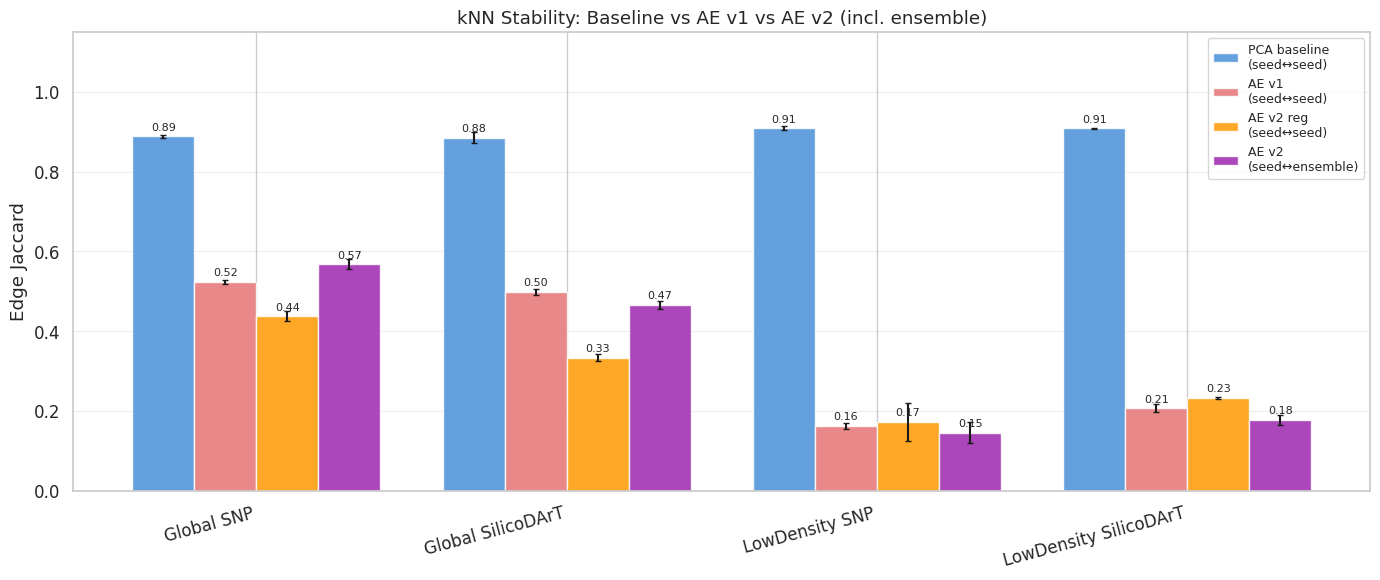

✓ Saved


In [9]:
stab_v2_agg = stab_v2_df.groupby(["dataset", "type"])["jaccard"].agg(["mean", "std"]).reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
types_order = ["baseline_seed2seed", "v1_seed2seed", "v2_seed2seed", "v2_seed2ens"]
type_labels = ["PCA baseline\n(seed↔seed)", "AE v1\n(seed↔seed)",
               "AE v2 reg\n(seed↔seed)", "AE v2\n(seed↔ensemble)"]
colors_stab = ["#4A90D9", "#E57373", "#FF9800", "#9C27B0"]

x = np.arange(len(DATASETS))
n = len(types_order)
w = 0.8 / n

for i, (t, label, color) in enumerate(zip(types_order, type_labels, colors_stab)):
    means, stds = [], []
    for ds in DATASETS:
        row = stab_v2_agg[(stab_v2_agg["dataset"] == ds) & (stab_v2_agg["type"] == t)]
        if len(row) > 0:
            means.append(row["mean"].values[0])
            stds.append(row["std"].values[0] if not np.isnan(row["std"].values[0]) else 0)
        else:
            means.append(0)
            stds.append(0)
    offset = (i - n / 2 + 0.5) * w
    bars = ax.bar(x + offset, means, w, yerr=stds, label=label,
                  color=color, capsize=2, alpha=0.85)
    for bar, m in zip(bars, means):
        if m > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f"{m:.2f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([ds_labels[d] for d in DATASETS], rotation=15, ha="right")
ax.set_ylabel("Edge Jaccard")
ax.set_title("kNN Stability: Baseline vs AE v1 vs AE v2 (incl. ensemble)")
ax.legend(fontsize=9)
ax.set_ylim(0, 1.15)
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / "07_stability_v2_comparison.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("✓ Saved")

## 9. Tabla resumen: baseline vs ae-v1 vs ae-v2

In [10]:
rows_v2 = []
for ds in DATASETS:
    # Baseline
    val = load_validation(ds)
    bl_t = val["trustworthiness"]["mean"]
    bl_stab = stab_v2_df[(stab_v2_df["dataset"]==ds) & (stab_v2_df["type"]=="baseline_seed2seed")]["jaccard"].mean()
    
    # AE v1
    v1_t = trust_df[trust_df["dataset"]==ds]["trust_ae_bottleneck64"].mean()
    v1_stab = stab_v2_df[(stab_v2_df["dataset"]==ds) & (stab_v2_df["type"]=="v1_seed2seed")]["jaccard"].mean()
    
    # AE v2 regularized
    v2r = trust_v2_df[(trust_v2_df["dataset"]==ds) & (trust_v2_df["variant"]=="v2_reg")]
    v2_t = v2r["trust_bn"].mean() if len(v2r) > 0 else None
    v2_stab = stab_v2_df[(stab_v2_df["dataset"]==ds) & (stab_v2_df["type"]=="v2_seed2seed")]["jaccard"].mean()
    
    # AE v2 ensemble
    v2e = trust_v2_df[(trust_v2_df["dataset"]==ds) & (trust_v2_df["variant"]=="v2_ensemble")]
    v2e_t = v2e["trust_bn"].values[0] if len(v2e) > 0 else None
    v2e_stab = stab_v2_df[(stab_v2_df["dataset"]==ds) & (stab_v2_df["type"]=="v2_seed2ens")]["jaccard"].mean()
    
    # AE v2 transfer (lowdensity only)
    v2tf = trust_v2_df[(trust_v2_df["dataset"]==ds) & (trust_v2_df["variant"]=="v2_transfer")]
    v2tf_t = v2tf["trust_bn"].mean() if len(v2tf) > 0 else None
    
    row = {
        "Dataset": ds_labels[ds],
        "BL Trust": f"{bl_t:.4f}",
        "v1 Trust": f"{v1_t:.4f}",
        "v2 Trust": f"{v2_t:.4f}" if v2_t else "—",
        "v2 ens Trust": f"{v2e_t:.4f}" if v2e_t else "—",
        "v2 TL Trust": f"{v2tf_t:.4f}" if v2tf_t else "—",
        "BL Stab": f"{bl_stab:.3f}",
        "v1 Stab": f"{v1_stab:.3f}",
        "v2 Stab": f"{v2_stab:.3f}",
        "v2 ens↔seed": f"{v2e_stab:.3f}",
        "Best": "v2 ens" if (v2e_t and v2e_t >= bl_t) else "baseline",
    }
    rows_v2.append(row)

summary_v2 = pd.DataFrame(rows_v2)
styled = summary_v2.style.set_caption("Comparación completa: Baseline vs AE v1 vs AE v2")
styled

,Dataset,BL Trust,v1 Trust,v2 Trust,v2 ens Trust,v2 TL Trust,BL Stab,v1 Stab,v2 Stab,v2 ens↔seed,Best
0,Global SNP,0.9756,0.9879,0.9822,0.9847,—,0.888,0.524,0.438,0.568,v2 ens
1,Global SilicoDArT,0.9792,0.9889,0.9768,0.9799,—,0.885,0.498,0.333,0.466,v2 ens
2,LowDensity SNP,0.9334,0.8360,0.8438,0.7844,0.6583,0.909,0.163,0.173,0.146,baseline
3,LowDensity SilicoDArT,0.9105,0.8288,0.8531,0.7704,0.7717,0.908,0.207,0.233,0.178,baseline


---
# Level 2: Masked Genotype Transformer (MGT)

Arquitectura tipo BERT para genotipos:
- **Value embedding**: {0, 1, 2, MASK, CLS} → d=128
- **Positional encoding**: sinusoidal (parameter-free, soporta sub-sampling)
- **Encoder**: TransformerEncoder(L=4, h=4, ff=256, pre-LN)
- **Training**: masked prediction (15%) sobre sub-muestras aleatorias de 512 markers
- **Inference**: Monte Carlo CLS — promedio de CLS sobre 20 subsets aleatorios
- **Parámetros**: ~556k (vs ~1.2M del AE)

Tag: `mgt-v1`, 50 epochs, 3 seeds, 4 datasets.

In [7]:
## ── MGT setup ──────────────────────────────────────────────
MGT_TAG = "mgt-v1"

def load_nodes_mgt(ds, seed):
    p = ROOT / "experiments" / ds / MGT_TAG / f"seed{seed}" / "ae_embedding_nodes.json"
    with open(p) as f:
        return json.load(f)

def load_edges_mgt(ds, seed):
    p = ROOT / "experiments" / ds / MGT_TAG / f"seed{seed}" / "ae_embedding_edges.json"
    with open(p) as f:
        return json.load(f)

def load_stats_mgt(ds, seed):
    p = ROOT / "experiments" / ds / MGT_TAG / f"seed{seed}" / "ae_embedding_stats.json"
    with open(p) as f:
        return json.load(f)

# Quick stats overview
for ds in DATASETS:
    stats = [load_stats_mgt(ds, s) for s in SEEDS]
    vl = [s["best_val_loss"] for s in stats]
    va = [s["best_val_acc"] for s in stats]
    ep = [s["epochs_trained"] for s in stats]
    print(f"{ds_labels[ds]:25s}: val_loss={np.mean(vl):.4f}±{np.std(vl):.4f}  "
          f"val_acc={np.mean(va):.3f}±{np.std(va):.3f}  "
          f"epochs={ep}  params={stats[0]['n_params']:,}")

print("\n✓ MGT setup ready")

Global SNP               : val_loss=0.6655±0.0010  val_acc=0.703±0.001  epochs=[50, 47, 46]  params=556,099
Global SilicoDArT        : val_loss=0.5140±0.0006  val_acc=0.743±0.001  epochs=[50, 45, 43]  params=555,970
LowDensity SNP           : val_loss=0.6783±0.0021  val_acc=0.587±0.005  epochs=[12, 4, 22]  params=556,099
LowDensity SilicoDArT    : val_loss=0.3291±0.0024  val_acc=0.843±0.001  epochs=[45, 21, 33]  params=555,970

✓ MGT setup ready


## 10. Trustworthiness — MGT (Level 2) vs baseline vs AE

In [8]:
trust_mgt_results = []

for ds in DATASETS:
    print(f"\n--- {ds_labels[ds]} ---")
    X_raw, sample_ids_raw, sample_meta = load_genotypes(ROOT / DS_INPUTS[ds])
    X_raw, _ = filter_missingness(X_raw, sample_thresh=0.50, marker_thresh=0.50)
    imp = SimpleImputer(strategy="most_frequent")
    X_high = imp.fit_transform(X_raw)
    k = 15
    
    for seed in SEEDS:
        nodes = load_nodes_mgt(ds, seed)
        bn = np.array([n["bottleneck"] for n in nodes])
        emb2d = np.array([n["embedding"] for n in nodes])
        t_bn = trustworthiness(X_high, bn, n_neighbors=min(k, len(nodes)-1))
        t_2d = trustworthiness(X_high, emb2d, n_neighbors=min(k, len(nodes)-1))
        
        stats = load_stats_mgt(ds, seed)
        trust_mgt_results.append({
            "dataset": ds, "seed": seed,
            "trust_bn": t_bn, "trust_2d": t_2d,
            "val_loss": stats["best_val_loss"],
            "val_acc": stats["best_val_acc"],
            "epochs": stats["epochs_trained"],
            "cls_mc_std": stats.get("cls_mc_std", None),
        })
        print(f"  MGT seed={seed}: trust_bn={t_bn:.4f}  trust_2d={t_2d:.4f}  "
              f"val_loss={stats['best_val_loss']:.4f}  val_acc={stats['best_val_acc']:.3f}")

trust_mgt_df = pd.DataFrame(trust_mgt_results)

# Summary comparison
print("\n── Trustworthiness comparison (bottleneck) ──")
print(f"{'Dataset':25s} {'Baseline':>10s} {'AE v1':>10s} {'AE v2 reg':>10s} {'MGT':>10s}")
for ds in DATASETS:
    val = load_validation(ds)
    bl = val["trustworthiness"]["mean"]
    v1 = trust_df[trust_df["dataset"]==ds]["trust_ae_bottleneck64"].mean()
    v2r = trust_v2_df[(trust_v2_df["dataset"]==ds) & (trust_v2_df["variant"]=="v2_reg")]
    v2 = v2r["trust_bn"].mean() if len(v2r) > 0 else 0
    mgt = trust_mgt_df[trust_mgt_df["dataset"]==ds]["trust_bn"].mean()
    best = max(bl, v1, v2, mgt)
    markers = {"bl": bl, "v1": v1, "v2": v2, "mgt": mgt}
    winner = [k for k, v in markers.items() if v == best][0]
    print(f"{ds_labels[ds]:25s} {bl:10.4f} {v1:10.4f} {v2:10.4f} {mgt:10.4f}  ← {winner}")

print("\n✓ MGT trustworthiness computed")


--- Global SNP ---
  MGT seed=42: trust_bn=0.8028  trust_2d=0.7584  val_loss=0.6669  val_acc=0.702
  MGT seed=52: trust_bn=0.8041  trust_2d=0.7446  val_loss=0.6649  val_acc=0.704
  MGT seed=62: trust_bn=0.7918  trust_2d=0.7381  val_loss=0.6647  val_acc=0.703

--- Global SilicoDArT ---
  MGT seed=42: trust_bn=0.7830  trust_2d=0.7134  val_loss=0.5134  val_acc=0.744
  MGT seed=52: trust_bn=0.7800  trust_2d=0.7170  val_loss=0.5149  val_acc=0.743
  MGT seed=62: trust_bn=0.7784  trust_2d=0.7101  val_loss=0.5136  val_acc=0.743

--- LowDensity SNP ---
  MGT seed=42: trust_bn=0.6926  trust_2d=0.6291  val_loss=0.6798  val_acc=0.585
  MGT seed=52: trust_bn=0.7086  trust_2d=0.6395  val_loss=0.6797  val_acc=0.582
  MGT seed=62: trust_bn=0.7173  trust_2d=0.6487  val_loss=0.6753  val_acc=0.593

--- LowDensity SilicoDArT ---
  MGT seed=42: trust_bn=0.7183  trust_2d=0.6574  val_loss=0.3262  val_acc=0.843
  MGT seed=52: trust_bn=0.7056  trust_2d=0.6435  val_loss=0.3288  val_acc=0.844
  MGT seed=62: tru

### Fig 08 — Trustworthiness: baseline vs AE v1 vs AE v2 reg vs MGT

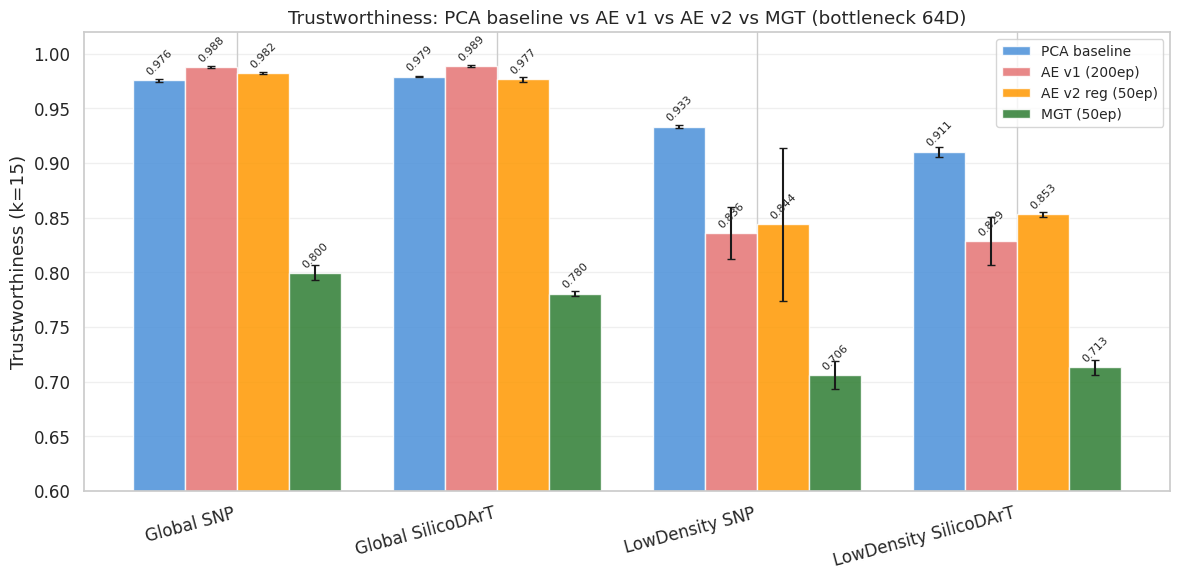

✓ Saved Fig 08


In [9]:
methods_all = {
    "PCA baseline": {},
    "AE v1 (200ep)": {},
    "AE v2 reg (50ep)": {},
    "MGT (50ep)": {},
}

for ds in DATASETS:
    val = load_validation(ds)
    methods_all["PCA baseline"][ds] = (val["trustworthiness"]["mean"], val["trustworthiness"]["std"])
    
    v1 = trust_df[trust_df["dataset"] == ds]["trust_ae_bottleneck64"]
    methods_all["AE v1 (200ep)"][ds] = (v1.mean(), v1.std())
    
    v2r = trust_v2_df[(trust_v2_df["dataset"] == ds) & (trust_v2_df["variant"] == "v2_reg")]
    if len(v2r) > 0:
        methods_all["AE v2 reg (50ep)"][ds] = (v2r["trust_bn"].mean(), v2r["trust_bn"].std())
    
    mgt = trust_mgt_df[trust_mgt_df["dataset"] == ds]
    methods_all["MGT (50ep)"][ds] = (mgt["trust_bn"].mean(), mgt["trust_bn"].std())

colors_all = ["#4A90D9", "#E57373", "#FF9800", "#2E7D32"]
fig, ax = plt.subplots(figsize=(12, 6))
n_m = len(methods_all)
x = np.arange(len(DATASETS))
w = 0.8 / n_m

for i, (method, ds_vals) in enumerate(methods_all.items()):
    means = [ds_vals.get(ds, (0, 0))[0] for ds in DATASETS]
    stds = [ds_vals.get(ds, (0, 0))[1] for ds in DATASETS]
    offset = (i - n_m / 2 + 0.5) * w
    bars = ax.bar(x + offset, means, w, yerr=stds, label=method,
                  color=colors_all[i], capsize=3, alpha=0.85)
    for bar, m in zip(bars, means):
        if m > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                    f"{m:.3f}", ha="center", va="bottom", fontsize=8, rotation=45)

ax.set_xticks(x)
ax.set_xticklabels([ds_labels[d] for d in DATASETS], rotation=15, ha="right")
ax.set_ylabel("Trustworthiness (k=15)")
ax.set_title("Trustworthiness: PCA baseline vs AE v1 vs AE v2 vs MGT (bottleneck 64D)")
ax.legend(fontsize=10)
ax.set_ylim(0.60, 1.02)
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / "08_trust_mgt_comparison.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("✓ Saved Fig 08")

## 11. Estabilidad kNN — MGT seed-to-seed

In [10]:
stab_mgt_results = []

for ds in DATASETS:
    print(f"\n--- {ds_labels[ds]} ---")
    
    # MGT seed-to-seed
    for s1, s2 in seed_pairs:
        e1 = load_edges_mgt(ds, s1)
        e2 = load_edges_mgt(ds, s2)
        j = compute_knn_jaccard(e1, e2)
        stab_mgt_results.append({
            "dataset": ds, "comparison": f"mgt s{s1}-s{s2}",
            "type": "mgt_seed2seed", "jaccard": j,
        })
        print(f"  MGT seed {s1}-{s2}: J={j:.4f}")
    
    # Reference: baseline, v1, v2 (recompute from stab_v2_df for consistency)
    for t in ["baseline_seed2seed", "v1_seed2seed", "v2_seed2seed"]:
        rows = stab_v2_df[(stab_v2_df["dataset"]==ds) & (stab_v2_df["type"]==t)]
        for _, r in rows.iterrows():
            stab_mgt_results.append({
                "dataset": ds, "comparison": r["comparison"],
                "type": t, "jaccard": r["jaccard"],
            })

stab_mgt_df = pd.DataFrame(stab_mgt_results)

# Summary
print("\n── Stability comparison (edge Jaccard) ──")
stab_agg = stab_mgt_df.groupby(["dataset", "type"])["jaccard"].mean().unstack()
for ds in DATASETS:
    row = stab_agg.loc[ds]
    print(f"{ds_labels[ds]:25s}  BL={row.get('baseline_seed2seed',0):.3f}  "
          f"v1={row.get('v1_seed2seed',0):.3f}  "
          f"v2={row.get('v2_seed2seed',0):.3f}  "
          f"MGT={row.get('mgt_seed2seed',0):.3f}")

print("\n✓ MGT stability computed")


--- Global SNP ---
  MGT seed 42-52: J=0.0491
  MGT seed 42-62: J=0.0480
  MGT seed 52-62: J=0.0472

--- Global SilicoDArT ---
  MGT seed 42-52: J=0.0296
  MGT seed 42-62: J=0.0280
  MGT seed 52-62: J=0.0296

--- LowDensity SNP ---
  MGT seed 42-52: J=0.0380
  MGT seed 42-62: J=0.0299
  MGT seed 52-62: J=0.0264

--- LowDensity SilicoDArT ---
  MGT seed 42-52: J=0.1132
  MGT seed 42-62: J=0.1106
  MGT seed 52-62: J=0.1084

── Stability comparison (edge Jaccard) ──
Global SNP                 BL=0.888  v1=0.524  v2=0.438  MGT=0.048
Global SilicoDArT          BL=0.885  v1=0.498  v2=0.333  MGT=0.029
LowDensity SNP             BL=0.909  v1=0.163  v2=0.173  MGT=0.031
LowDensity SilicoDArT      BL=0.908  v1=0.207  v2=0.233  MGT=0.111

✓ MGT stability computed


### Fig 09 — Stability: baseline vs AE v1 vs AE v2 vs MGT

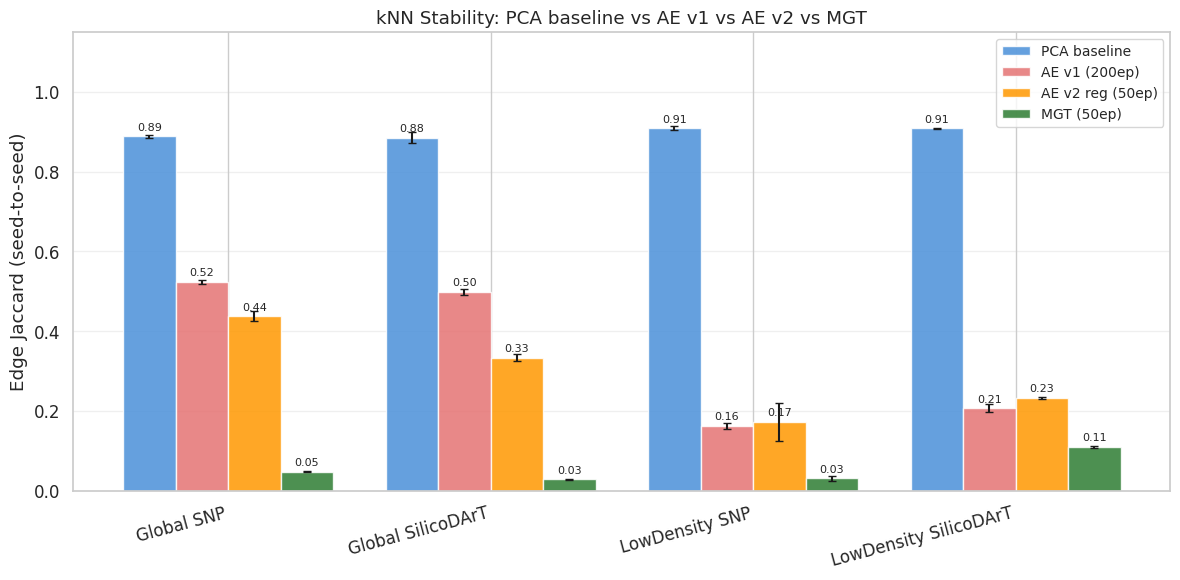

✓ Saved Fig 09


In [11]:
stab_mgt_agg = stab_mgt_df.groupby(["dataset", "type"])["jaccard"].agg(["mean", "std"]).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
types_order = ["baseline_seed2seed", "v1_seed2seed", "v2_seed2seed", "mgt_seed2seed"]
type_labels = ["PCA baseline", "AE v1 (200ep)", "AE v2 reg (50ep)", "MGT (50ep)"]
colors_stab2 = ["#4A90D9", "#E57373", "#FF9800", "#2E7D32"]

x = np.arange(len(DATASETS))
n = len(types_order)
w = 0.8 / n

for i, (t, label, color) in enumerate(zip(types_order, type_labels, colors_stab2)):
    means, stds = [], []
    for ds in DATASETS:
        row = stab_mgt_agg[(stab_mgt_agg["dataset"] == ds) & (stab_mgt_agg["type"] == t)]
        if len(row) > 0:
            means.append(row["mean"].values[0])
            stds.append(row["std"].values[0] if not np.isnan(row["std"].values[0]) else 0)
        else:
            means.append(0)
            stds.append(0)
    offset = (i - n / 2 + 0.5) * w
    bars = ax.bar(x + offset, means, w, yerr=stds, label=label,
                  color=color, capsize=3, alpha=0.85)
    for bar, m in zip(bars, means):
        if m > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f"{m:.2f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([ds_labels[d] for d in DATASETS], rotation=15, ha="right")
ax.set_ylabel("Edge Jaccard (seed-to-seed)")
ax.set_title("kNN Stability: PCA baseline vs AE v1 vs AE v2 vs MGT")
ax.legend(fontsize=10)
ax.set_ylim(0, 1.15)
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / "09_stability_mgt_comparison.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("✓ Saved Fig 09")

## 12. Tabla resumen final: baseline vs AE v1 vs AE v2 vs MGT

In [12]:
rows_final = []
for ds in DATASETS:
    # Baseline
    val = load_validation(ds)
    bl_t = val["trustworthiness"]["mean"]
    bl_stab = stab_mgt_df[(stab_mgt_df["dataset"]==ds) & (stab_mgt_df["type"]=="baseline_seed2seed")]["jaccard"].mean()
    
    # AE v1
    v1_t = trust_df[trust_df["dataset"]==ds]["trust_ae_bottleneck64"].mean()
    v1_stab = stab_mgt_df[(stab_mgt_df["dataset"]==ds) & (stab_mgt_df["type"]=="v1_seed2seed")]["jaccard"].mean()
    
    # AE v2 reg
    v2r = trust_v2_df[(trust_v2_df["dataset"]==ds) & (trust_v2_df["variant"]=="v2_reg")]
    v2_t = v2r["trust_bn"].mean() if len(v2r) > 0 else None
    v2_stab = stab_mgt_df[(stab_mgt_df["dataset"]==ds) & (stab_mgt_df["type"]=="v2_seed2seed")]["jaccard"].mean()
    
    # MGT
    mgt = trust_mgt_df[trust_mgt_df["dataset"]==ds]
    mgt_t = mgt["trust_bn"].mean()
    mgt_stab = stab_mgt_df[(stab_mgt_df["dataset"]==ds) & (stab_mgt_df["type"]=="mgt_seed2seed")]["jaccard"].mean()
    mgt_acc = mgt["val_acc"].mean()
    
    # Determine best trust
    candidates = {"BL": bl_t, "v1": v1_t, "v2": v2_t or 0, "MGT": mgt_t}
    best = max(candidates, key=lambda k: candidates[k])
    
    row = {
        "Dataset": ds_labels[ds],
        "n": val.get("n_samples", "?"),
        "BL Trust": f"{bl_t:.4f}",
        "v1 Trust": f"{v1_t:.4f}",
        "v2 Trust": f"{v2_t:.4f}" if v2_t else "—",
        "MGT Trust": f"{mgt_t:.4f}",
        "BL Stab": f"{bl_stab:.3f}",
        "v1 Stab": f"{v1_stab:.3f}",
        "v2 Stab": f"{v2_stab:.3f}",
        "MGT Stab": f"{mgt_stab:.3f}",
        "MGT Acc": f"{mgt_acc:.3f}",
        "Best Trust": best,
    }
    rows_final.append(row)

summary_final = pd.DataFrame(rows_final)
styled = summary_final.style.set_caption(
    "Comparación completa: PCA baseline vs AE v1 vs AE v2 vs MGT (Level 2)"
)
styled

,Dataset,n,BL Trust,v1 Trust,v2 Trust,MGT Trust,BL Stab,v1 Stab,v2 Stab,MGT Stab,MGT Acc,Best Trust
0,Global SNP,?,0.9756,0.9879,0.9822,0.7996,0.888,0.524,0.438,0.048,0.703,v1
1,Global SilicoDArT,?,0.9792,0.9889,0.9768,0.7804,0.885,0.498,0.333,0.029,0.743,v1
2,LowDensity SNP,?,0.9334,0.8360,0.8438,0.7062,0.909,0.163,0.173,0.031,0.587,BL
3,LowDensity SilicoDArT,?,0.9105,0.8288,0.8531,0.7131,0.908,0.207,0.233,0.111,0.843,BL


## 13. Level A — Frontera de Estabilidad Representacional

**Pregunta**: ¿A partir de qué tamaño muestral $n^*$ las representaciones aprendidas (AE) superan a PCA en trustworthiness?

**Diseño**: Submuestreo del dataset Global SNP ($n_{max}$=5970, $p$=20069) a 14 tamaños de muestra × 3 seeds. Para cada condición se entrenan PCA baseline y AE v1 (bn64, 200 epochs). Se mide:
- **Trust**: Trustworthiness ($k$=15) entre espacio original y embedding
- **Stability**: Jaccard de aristas kNN entre seeds

In [2]:
# ── Load frontier results ──
import json
with open("../experiments/frontier/results_global_snp.json") as f:
    frontier_data = json.load(f)

frontier_df = pd.DataFrame(frontier_data)
frontier_df["ratio_n_p_pct"] = (frontier_df["ratio_n_p"] * 100).round(1)

# Show full table
cols_show = [
    "n_samples", "ratio_n_p_pct",
    "pca_trust_mean", "pca_trust_std",
    "ae_trust_mean", "ae_trust_std",
    "trust_delta", "ae_wins_trust",
    "pca_stab_mean", "ae_stab_mean", "stab_delta",
]
display_df = frontier_df[cols_show].copy()
display_df.columns = [
    "n", "n/p %",
    "PCA Trust", "PCA σ",
    "AE Trust", "AE σ",
    "Δ Trust", "AE wins?",
    "PCA Stab", "AE Stab", "Δ Stab",
]
print("═" * 70)
print("  REPRESENTATION STABILITY FRONTIER — Global SNP")
print("═" * 70)
print(f"  Dataset: {frontier_data[0]['n_markers']} markers, max n={frontier_data[-1]['n_samples']}")
print(f"  Points: {len(frontier_data)} sample sizes × 3 seeds")
print()

# Find crossover
for i in range(1, len(frontier_data)):
    if frontier_data[i-1]["trust_delta"] <= 0 and frontier_data[i]["trust_delta"] > 0:
        lo, hi = frontier_data[i-1]["n_samples"], frontier_data[i]["n_samples"]
        ratio_lo = frontier_data[i-1]["ratio_n_p"]
        ratio_hi = frontier_data[i]["ratio_n_p"]
        print(f"  ★ Crossover n* ∈ [{lo}, {hi}]  (n/p ∈ [{ratio_lo:.3f}, {ratio_hi:.3f}])")
        break

print()
styled = display_df.style.set_caption(
    "Frontier: PCA vs AE Trust & Stability by sample size"
).format(precision=4)
styled

══════════════════════════════════════════════════════════════════════
  REPRESENTATION STABILITY FRONTIER — Global SNP
══════════════════════════════════════════════════════════════════════
  Dataset: 20069 markers, max n=5970
  Points: 14 sample sizes × 3 seeds

  ★ Crossover n* ∈ [4000, 4100]  (n/p ∈ [0.199, 0.204])



,n,n/p %,PCA Trust,PCA σ,AE Trust,AE σ,Δ Trust,AE wins?,PCA Stab,AE Stab,Δ Stab
0,100,0.5000,0.9393,0.0021,0.8859,0.0164,-0.0534,False,0.8045,0.3935,-0.4110
1,200,1.0000,0.9319,0.0017,0.8695,0.0073,-0.0624,False,0.8605,0.3089,-0.5516
2,500,2.5000,0.9616,0.0000,0.8750,0.0205,-0.0866,False,0.8967,0.2078,-0.6889
3,1000,5.0000,0.9711,0.0000,0.9607,0.0035,-0.0104,False,0.9853,0.4582,-0.5272
4,2000,10.0000,0.9782,0.0001,0.9266,0.0259,-0.0517,False,0.9863,0.1728,-0.8135
5,3000,15.0000,0.9823,0.0000,0.9811,0.0012,-0.0013,False,0.9865,0.4989,-0.4876
6,3500,17.4000,0.9831,0.0000,0.9827,0.0015,-0.0004,False,0.9856,0.4995,-0.4861
7,4000,19.9000,0.9837,0.0000,0.9782,0.0028,-0.0055,False,0.9882,0.3966,-0.5916
8,4100,20.4000,0.9840,0.0000,0.9841,0.0003,0.0001,True,0.9871,0.5029,-0.4843
9,4200,20.9000,0.9841,0.0000,0.9837,0.0019,-0.0004,False,0.9869,0.4512,-0.5357


### Fig 10 — Frontera de Crossover Trust (PCA vs AE)

✓ Saved Fig 10


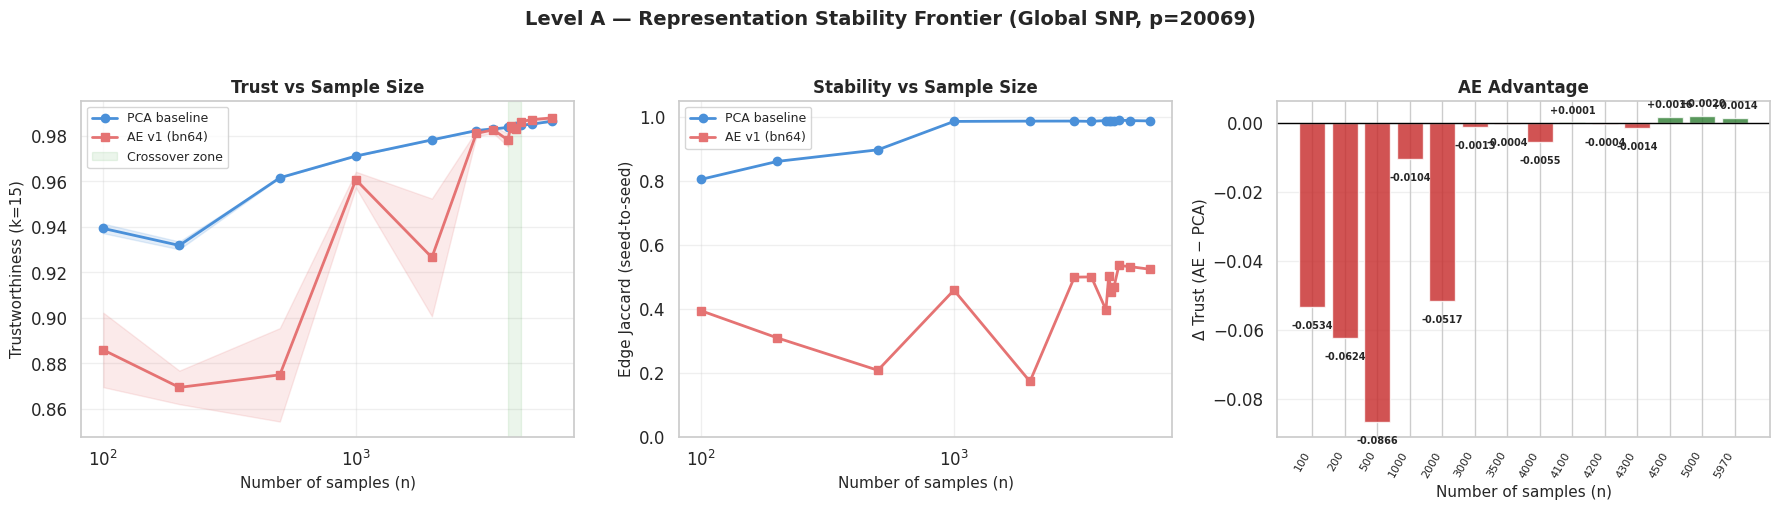

In [3]:
# ── Fig 10: 3-panel frontier plot ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Trust vs n
ax = axes[0]
ax.plot(frontier_df["n_samples"], frontier_df["pca_trust_mean"], "o-",
        color="#4A90D9", label="PCA baseline", markersize=6, linewidth=2)
ax.fill_between(frontier_df["n_samples"],
                frontier_df["pca_trust_mean"] - frontier_df["pca_trust_std"],
                frontier_df["pca_trust_mean"] + frontier_df["pca_trust_std"],
                alpha=0.15, color="#4A90D9")
ax.plot(frontier_df["n_samples"], frontier_df["ae_trust_mean"], "s-",
        color="#E57373", label="AE v1 (bn64)", markersize=6, linewidth=2)
ax.fill_between(frontier_df["n_samples"],
                frontier_df["ae_trust_mean"] - frontier_df["ae_trust_std"],
                frontier_df["ae_trust_mean"] + frontier_df["ae_trust_std"],
                alpha=0.15, color="#E57373")
# Shade crossover zone
ax.axvspan(4000, 4500, alpha=0.08, color="green", label="Crossover zone")
ax.set_xlabel("Number of samples (n)", fontsize=11)
ax.set_ylabel("Trustworthiness (k=15)", fontsize=11)
ax.set_title("Trust vs Sample Size", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xscale("log")

# Panel 2: Stability vs n
ax = axes[1]
stab_df = frontier_df.dropna(subset=["pca_stab_mean", "ae_stab_mean"])
ax.plot(stab_df["n_samples"], stab_df["pca_stab_mean"], "o-",
        color="#4A90D9", label="PCA baseline", markersize=6, linewidth=2)
ax.plot(stab_df["n_samples"], stab_df["ae_stab_mean"], "s-",
        color="#E57373", label="AE v1 (bn64)", markersize=6, linewidth=2)
ax.set_xlabel("Number of samples (n)", fontsize=11)
ax.set_ylabel("Edge Jaccard (seed-to-seed)", fontsize=11)
ax.set_title("Stability vs Sample Size", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xscale("log")
ax.set_ylim(0, 1.05)

# Panel 3: Δ Trust bar
ax = axes[2]
colors = ["#2E7D32" if d > 0 else "#C62828" for d in frontier_df["trust_delta"]]
bars = ax.bar(range(len(frontier_df)), frontier_df["trust_delta"], color=colors, alpha=0.8)
ax.set_xticks(range(len(frontier_df)))
ax.set_xticklabels([str(n) for n in frontier_df["n_samples"]], rotation=60, ha="right", fontsize=8)
ax.set_xlabel("Number of samples (n)", fontsize=11)
ax.set_ylabel("Δ Trust (AE − PCA)", fontsize=11)
ax.set_title("AE Advantage", fontsize=12, fontweight="bold")
ax.axhline(0, color="black", linewidth=1)
ax.grid(axis="y", alpha=0.3)
for i, (delta, n) in enumerate(zip(frontier_df["trust_delta"], frontier_df["n_samples"])):
    ax.text(i, delta + (0.002 if delta >= 0 else -0.004),
            f"{delta:+.4f}", ha="center", va="bottom" if delta >= 0 else "top",
            fontsize=7, fontweight="bold")

fig.suptitle("Level A — Representation Stability Frontier (Global SNP, p=20069)",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig("../experiments/frontier/fig10_frontier_notebook.png", dpi=300, bbox_inches="tight")
print("✓ Saved Fig 10")
plt.show()

### Hallazgos Level A

| Hallazgo | Detalle |
|----------|---------|
| **Crossover trust n*** | ∈ [4000, 4500] → ratio n/p ≈ 0.20–0.22 |
| **Zona de transición** | n ∈ [3000, 5970]: Δtrust < 0.005 en ambas direcciones |
| **Stability gap** | AE stability ~0.50 vs PCA ~0.99 **en todos los tamaños** |
| **Implicación** | AE puede igualar/superar trust de PCA solo con n/p > 0.20, pero la estabilidad sigue siendo inaceptable |

**Conclusión**: El cuello de botella del AE no es solo n/p — la inestabilidad inter-seed es estructural (inicialización aleatoria, dropout, scheduling). Para que AE sea útil en genómica de conservación, se necesita resolver estabilidad antes que trust. → Proceder a Level B (Marker Subsampling).

## 14. Panel QA & Geometry Diagnostics (Módulo 1)

Correspondence-free characterization of each genotyping panel.
All metrics are intra-dataset — no cross-panel alignment.

**Metrics**: effective rank, PC1/PC2 dominance, kNN distance stats, reciprocal kNN rate, connected components, QA flags.

In [4]:
# ── Load panel diagnostics results ──────────────────────────────────────
import json
from pathlib import Path

diag_path = ROOT / "experiments" / "diagnostics" / "diagnostics_all.json"
with open(diag_path) as f:
    diag_data = json.load(f)

# Build summary table
diag_rows = []
for d in diag_data:
    diag_rows.append({
        "Panel": d["label"],
        "n": d["n_samples"],
        "p": d["n_markers"],
        "n/p": d["ratio_n_p"],
        "Missing %": round(d["missingness"]["missing_rate"] * 100, 1),
        "PC1 %": d["pca"]["pc1_var_pct"],
        "Eff. Rank": d["pca"]["effective_rank"],
        "kNN CV": d["knn_distances"]["cv"],
        "kNN Skew": d["knn_distances"]["skewness"],
        "Reciprocity": d["reciprocal_knn"]["reciprocal_rate"],
        "Components": d["components"]["n_components"],
        "Giant %": round(d["components"]["giant_component_ratio"] * 100, 1),
        "Flags": "; ".join(d["flags"]),
    })

import pandas as pd
diag_df = pd.DataFrame(diag_rows)
print("Panel QA & Geometry Diagnostics (k=15, cosine on PCA-30D)")
print("=" * 80)
display(diag_df.style.format({
    "n/p": "{:.3f}",
    "Missing %": "{:.1f}%",
    "PC1 %": "{:.2f}%",
    "Eff. Rank": "{:.1f}",
    "kNN CV": "{:.3f}",
    "kNN Skew": "{:.3f}",
    "Reciprocity": "{:.3f}",
    "Giant %": "{:.1f}%",
}).set_caption("Table 5: Panel QA Diagnostics"))

Panel QA & Geometry Diagnostics (k=15, cosine on PCA-30D)


,Panel,n,p,n/p,Missing %,PC1 %,Eff. Rank,kNN CV,kNN Skew,Reciprocity,Components,Giant %,Flags
0,Global SNP,5970,20069,0.297,5.5%,9.49%,10.4,1.348,2.233,0.648,9,96.0%,DISCONNECTED (9 components)
1,Global SilicoDArT,5970,57715,0.103,3.2%,10.20%,10.0,1.350,2.235,0.647,5,98.5%,DISCONNECTED (5 components)
2,LowDensity SNP,630,62732,0.010,18.2%,8.87%,16.2,1.130,1.310,0.699,2,96.5%,HIGH-MISSINGNESS (18.2%); DISCONNECTED (2 components); EXTREME-WIDE (n/p=0.0100)
3,LowDensity SilicoDArT,635,38272,0.017,4.7%,9.46%,16.1,1.058,1.087,0.686,1,100.0%,EXTREME-WIDE (n/p=0.0166)


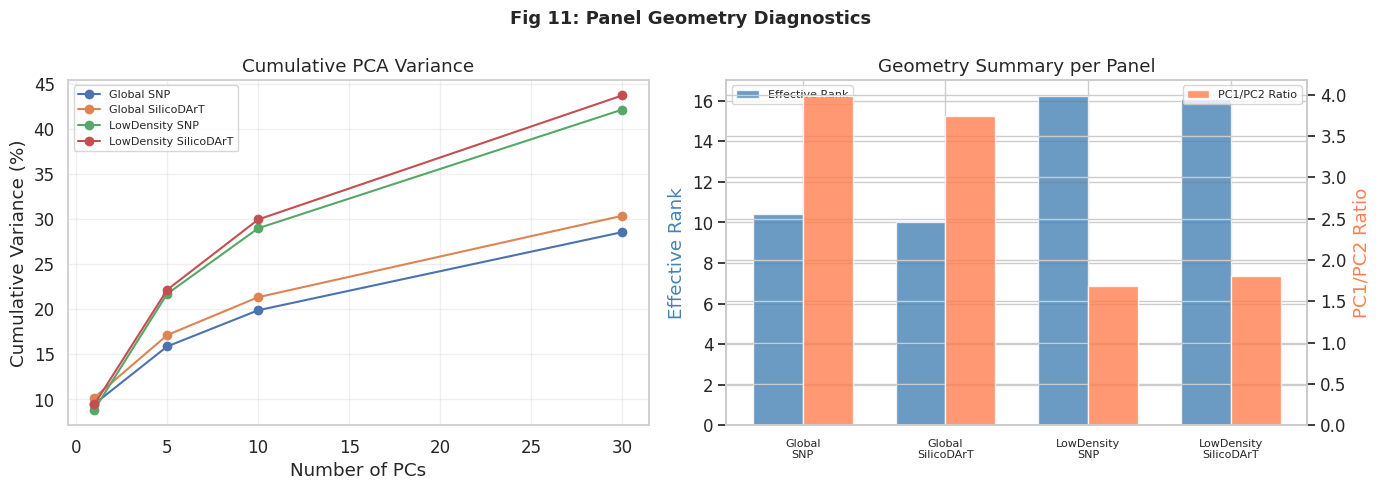

[saved] /shared/Code/OXOR/docs/figures/comparison/fig11_panel_geometry.png


In [5]:
# ── Fig 11: PCA Variance Spectrum Comparison ──────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

# Reload full diagnostics for eigenvalue curves
diag_full_path = ROOT / "experiments" / "diagnostics"
panel_spectra = {}
for ds_key in ["global_snp", "global_silico", "lowdensity_snp", "lowdensity_silico"]:
    fp = diag_full_path / f"diagnostics_{ds_key}.json"
    with open(fp) as f:
        d = json.load(f)
    panel_spectra[d["label"]] = d["pca"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: cumulative variance
ax = axes[0]
for label, pca_info in panel_spectra.items():
    cumvar = [pca_info["pc1_var_pct"]]
    if "cumvar_5" in pca_info:
        cumvar = [pca_info["pc1_var_pct"], pca_info.get("cumvar_5", 0),
                  pca_info.get("cumvar_10", 0), pca_info.get("cumvar_30", 0)]
        x = [1, 5, 10, 30]
        ax.plot(x, cumvar, "o-", label=label, markersize=6)
ax.set_xlabel("Number of PCs")
ax.set_ylabel("Cumulative Variance (%)")
ax.set_title("Cumulative PCA Variance")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right: effective rank + PC1/PC2 ratio
ax2 = axes[1]
panels = list(panel_spectra.keys())
eff_ranks = [panel_spectra[p]["effective_rank"] for p in panels]
pc1_pc2 = [panel_spectra[p]["pc1_pc2_ratio"] for p in panels]

x_pos = np.arange(len(panels))
w = 0.35
ax2.bar(x_pos - w/2, eff_ranks, w, label="Effective Rank", color="steelblue", alpha=0.8)
ax2_twin = ax2.twinx()
ax2_twin.bar(x_pos + w/2, pc1_pc2, w, label="PC1/PC2 Ratio", color="coral", alpha=0.8)

ax2.set_xticks(x_pos)
ax2.set_xticklabels([p.replace(" ", "\n") for p in panels], fontsize=8)
ax2.set_ylabel("Effective Rank", color="steelblue")
ax2_twin.set_ylabel("PC1/PC2 Ratio", color="coral")
ax2.set_title("Geometry Summary per Panel")
ax2.legend(loc="upper left", fontsize=8)
ax2_twin.legend(loc="upper right", fontsize=8)

fig.suptitle("Fig 11: Panel Geometry Diagnostics", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig11_panel_geometry.png", dpi=DPI, bbox_inches="tight")
plt.show()
print(f"[saved] {FIG_DIR / 'fig11_panel_geometry.png'}")

## 15. Robustness Curves (Módulo 2)

Sensitivity of graph topology and PCA geometry to controlled perturbations —
all intra-dataset (correspondence-free).

**Perturbations**: marker subsampling {5,10,20,50,80}%, missing injection +{0,5,10,20}% MCAR, imputation mode vs median.

**Metrics**: Jaccard neighbors, kNN distance drift, PCA subspace similarity (principal angles).

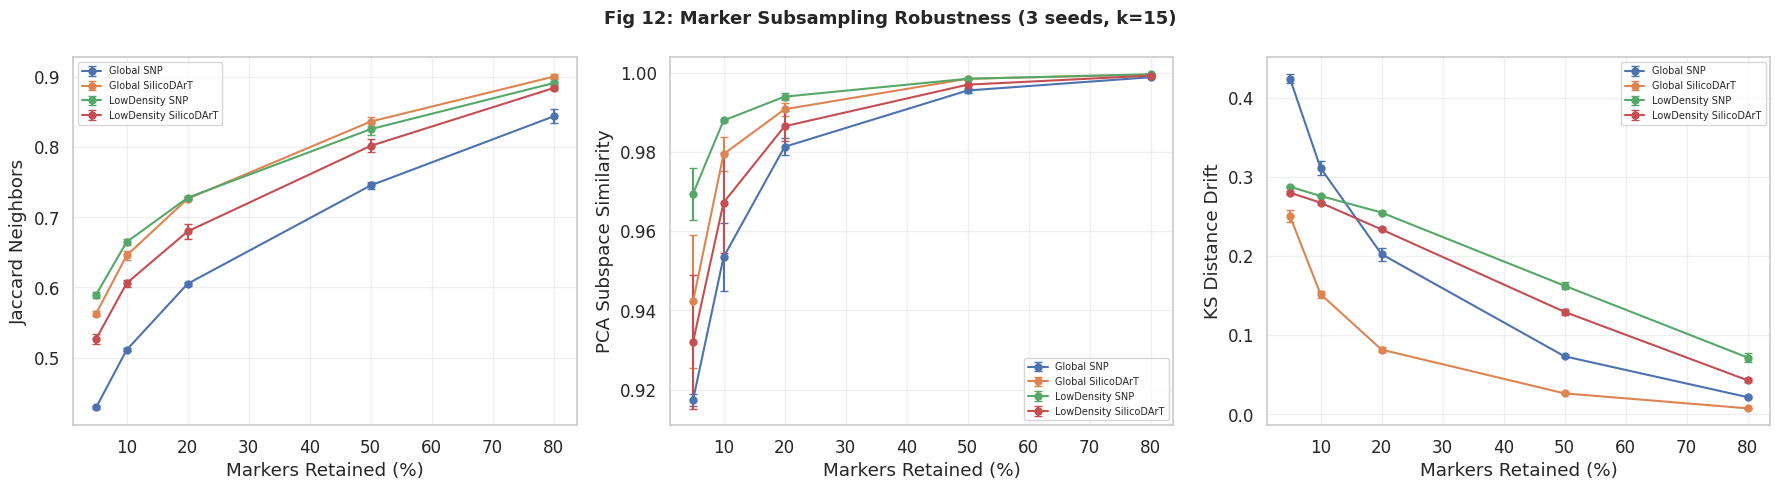

[saved] /shared/Code/OXOR/docs/figures/comparison/fig12_marker_subsampling.png


In [6]:
# ── Load robustness results ────────────────────────────────────────────
rob_path = ROOT / "experiments" / "robustness" / "robustness_all.json"
with open(rob_path) as f:
    rob_data = json.load(f)

# ── Fig 12: Marker Subsampling Curves ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_cols = [
    ("jaccard_neighbors", "Jaccard Neighbors"),
    ("subspace_similarity", "PCA Subspace Similarity"),
    ("distance_ks", "KS Distance Drift"),
]

for ax, (metric, ylabel) in zip(axes, metrics_cols):
    for ds_result in rob_data:
        label = ds_result["label"]
        rows = ds_result["marker_subsampling"]
        fracs = sorted(set(r["fraction"] for r in rows))
        means = []
        stds = []
        for frac in fracs:
            vals = [r[metric] for r in rows if r["fraction"] == frac]
            means.append(np.mean(vals))
            stds.append(np.std(vals))
        ax.errorbar([f * 100 for f in fracs], means, yerr=stds,
                    marker="o", capsize=3, label=label, markersize=5)
    ax.set_xlabel("Markers Retained (%)")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

fig.suptitle("Fig 12: Marker Subsampling Robustness (3 seeds, k=15)", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig12_marker_subsampling.png", dpi=DPI, bbox_inches="tight")
plt.show()
print(f"[saved] {FIG_DIR / 'fig12_marker_subsampling.png'}")

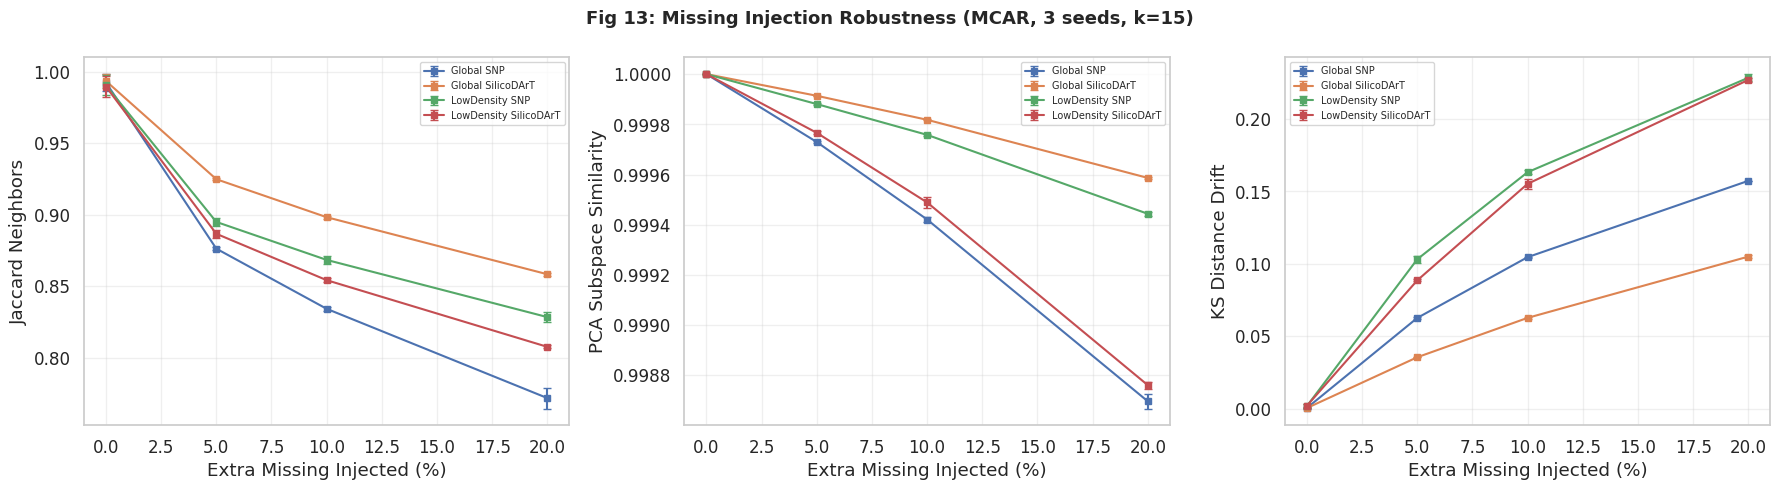

[saved] /shared/Code/OXOR/docs/figures/comparison/fig13_missing_injection.png


In [7]:
# ── Fig 13: Missing Injection Curves ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (metric, ylabel) in zip(axes, metrics_cols):
    for ds_result in rob_data:
        label = ds_result["label"]
        rows = ds_result["missing_injection"]
        rates = sorted(set(r["extra_rate"] for r in rows))
        means = []
        stds = []
        for rate in rates:
            vals = [r[metric] for r in rows if r["extra_rate"] == rate]
            means.append(np.mean(vals))
            stds.append(np.std(vals))
        ax.errorbar([r * 100 for r in rates], means, yerr=stds,
                    marker="s", capsize=3, label=label, markersize=5)
    ax.set_xlabel("Extra Missing Injected (%)")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

fig.suptitle("Fig 13: Missing Injection Robustness (MCAR, 3 seeds, k=15)", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig13_missing_injection.png", dpi=DPI, bbox_inches="tight")
plt.show()
print(f"[saved] {FIG_DIR / 'fig13_missing_injection.png'}")

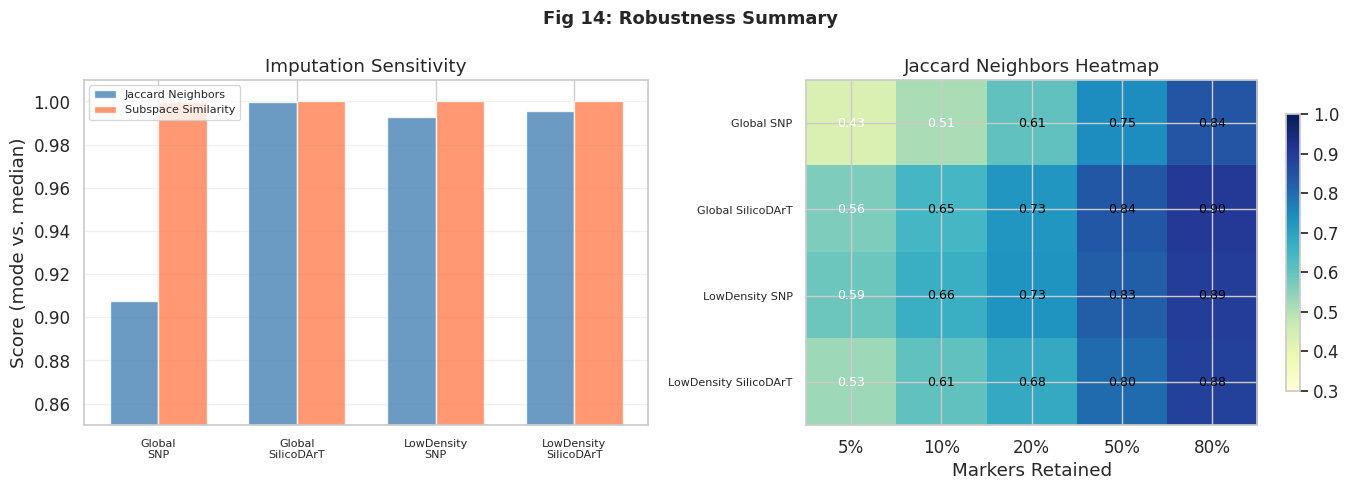

[saved] /shared/Code/OXOR/docs/figures/comparison/fig14_robustness_summary.png


In [8]:
# ── Fig 14: Imputation Sensitivity + Combined Robustness Summary ─────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Imputation comparison (mode vs median)
imp_labels, imp_jn, imp_ss = [], [], []
for ds_result in rob_data:
    imp_labels.append(ds_result["label"])
    rows = ds_result["imputation_comparison"]
    imp_jn.append(np.mean([r["jaccard_neighbors"] for r in rows]))
    imp_ss.append(np.mean([r["subspace_similarity"] for r in rows]))

x_pos = np.arange(len(imp_labels))
w = 0.35
ax1.bar(x_pos - w/2, imp_jn, w, label="Jaccard Neighbors", color="steelblue", alpha=0.8)
ax1.bar(x_pos + w/2, imp_ss, w, label="Subspace Similarity", color="coral", alpha=0.8)
ax1.set_xticks(x_pos)
ax1.set_xticklabels([l.replace(" ", "\n") for l in imp_labels], fontsize=8)
ax1.set_ylabel("Score (mode vs. median)")
ax1.set_title("Imputation Sensitivity")
ax1.set_ylim(0.85, 1.01)
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3, axis="y")

# Right: Robustness heatmap (Jaccard neighbors at each marker fraction × dataset)
fracs = [0.05, 0.10, 0.20, 0.50, 0.80]
heat_data = []
heat_labels = []
for ds_result in rob_data:
    heat_labels.append(ds_result["label"])
    row_vals = []
    for frac in fracs:
        vals = [r["jaccard_neighbors"] for r in ds_result["marker_subsampling"]
                if r["fraction"] == frac]
        row_vals.append(np.mean(vals))
    heat_data.append(row_vals)

heat_arr = np.array(heat_data)
im = ax2.imshow(heat_arr, aspect="auto", cmap="YlGnBu", vmin=0.3, vmax=1.0)
ax2.set_xticks(range(len(fracs)))
ax2.set_xticklabels([f"{f*100:.0f}%" for f in fracs])
ax2.set_yticks(range(len(heat_labels)))
ax2.set_yticklabels(heat_labels, fontsize=8)
ax2.set_xlabel("Markers Retained")
ax2.set_title("Jaccard Neighbors Heatmap")

# Annotate cells
for i in range(len(heat_labels)):
    for j in range(len(fracs)):
        ax2.text(j, i, f"{heat_arr[i, j]:.2f}",
                 ha="center", va="center", fontsize=9,
                 color="white" if heat_arr[i, j] < 0.6 else "black")
fig.colorbar(im, ax=ax2, shrink=0.8)

fig.suptitle("Fig 14: Robustness Summary", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig14_robustness_summary.png", dpi=DPI, bbox_inches="tight")
plt.show()
print(f"[saved] {FIG_DIR / 'fig14_robustness_summary.png'}")

### Hallazgos Módulos 1-2

**Módulo 1 — Panel QA**:
- Effective rank ~10-16: moderate intrinsic dimensionality, PC1 explains only ~9-10% (no single-axis collapse).
- Reciprocal kNN rate ~0.65-0.70: healthy neighborhood structure — most neighbors see each other.
- Small disconnected components (2-9) in SNP datasets; SilicoDArT panels are fully connected.
- LowDensity panels flagged as **EXTREME-WIDE** (n/p ≤ 0.017): far more markers than samples.

**Módulo 2 — Robustness Curves**:
- **Marker subsampling**: Jaccard neighbors degrades gracefully (0.43→0.90 from 5%→80%). Subspace similarity remains >0.91 even at 5%, confirming the PCA geometry is robust to marker dropout.
- **Missing injection**: Adding 20% extra MCAR reduces Jaccard neighbors to ~0.77-0.86 but subspace similarity stays >0.998. The topology is sensitive locally but the global structure is stable.
- **Imputation (mode vs. median)**: Negligible impact on SilicoDArT (Jaccard ~1.0); small but measurable on SNP (Jaccard ~0.91 for Global SNP). This confirms the pipeline's robustness to this methodological choice.
- All robustness analyses are **correspondence-free** — no cross-panel alignment assumed.